# מטלת סיכום חלק 2 — חיזוי דירוג סרטים

במחברת זו נבנה מודל Machine Learning שמטרתו לחזות את הדירוג הממוצע של סרט (`averageRating`) על בסיס מידע שהיה ידוע לפני יציאת הסרט לאקרנים.

בשלב הראשון נטען את קובץ הנתונים, נבדוק את מבנה הדאטה, נזהה עמודות חסרות או בעייתיות, ונבין אילו עמודות מותר ואסור להכניס למודל כדי להימנע מ-Data Leakage.

## 1. ייבוא ספריות בסיסיות

נייבא את הספריות המרכזיות שנשתמש בהן בתחילת העבודה:

- `pandas` לעבודה עם טבלאות נתונים.
- `numpy` לחישובים מספריים.
  
בנוסף נגדיר הצגה נוחה יותר של טבלאות, כך שנוכל לראות את כל העמודות ואת התוכן של עמודות טקסט ארוכות.

In [1]:
# ייבוא ספריית pandas לעבודה עם טבלאות נתונים מסוג DataFrame
import pandas as pd

# ייבוא ספריית numpy לחישובים מספריים
import numpy as np

# הגדרה שמאפשרת להציג את כל העמודות בטבלה, בלי ש-Jupyter יסתיר חלק מהן
pd.set_option("display.max_columns", None)

# הגדרה שמאפשרת לראות יותר טקסט בתוך תאים ארוכים, למשל תקציר סרט או רשימות
pd.set_option("display.max_colwidth", 200)

## 2. טעינת קובץ הנתונים

כעת נטען את קובץ ה-CSV של הדאטה לתוך DataFrame בשם `df`.

ה-DataFrame הוא בעצם טבלה בפייתון, בדומה לטבלת Excel.  
בהמשך כל פעולות הניקוי, ההכנה והמודלים יתבססו על הטבלה הזו.

In [2]:
# טעינת קובץ הנתונים לתוך DataFrame בשם df
df = pd.read_csv("dataset chen.csv")

# הצגת חמש השורות הראשונות כדי לוודא שהקובץ נטען בצורה תקינה
df.head()

C:\Users\mika8\AppData\Local\Temp\ipykernel_26176\561218063.py:2: DtypeWarning: Columns (0: budget) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset chen.csv")


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm0663237', 'nm0106122']",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm16127537', 'nm16127549']",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm0001960', 'nm0594856']",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN


## 3. בדיקת גודל הדאטה

נבדוק כמה שורות וכמה עמודות קיימות בקובץ.

מספר השורות מייצג את מספר הסרטים בדאטה, ומספר העמודות מייצג את מספר המשתנים שיש לנו על כל סרט.  
בדיקה זו עוזרת לנו להבין את היקף הנתונים לפני שמתחילים ניקוי ובניית מודלים.

In [3]:
# בדיקת מספר השורות והעמודות בדאטה
df.shape

(133884, 13)

## 4. הצגת שמות העמודות

נציג את שמות כל העמודות בדאטה כדי להבין אילו משתנים קיימים לנו.

שלב זה חשוב כי בהמשך נצטרך להחליט:
- איזו עמודה היא משתנה המטרה שאותו נרצה לחזות.
- אילו עמודות יכולות לשמש כמשתני הסבר למודל.
- אילו עמודות אסור להכניס למודל בגלל חשש ל-Data Leakage.

In [4]:
# הצגת שמות כל העמודות בדאטה
df.columns

Index(['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids',
       'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes',
       'budget', 'BoxOffice', 'plot'],
      dtype='str')

## 5. בדיקת מידע כללי על הדאטה

נשתמש ב-`info()` כדי לבדוק עבור כל עמודה:

- כמה ערכים לא חסרים יש בה.
- מה סוג הנתונים שלה.
- האם היא מזוהה כמספרית או כטקסטואלית.

שלב זה עוזר לזהות עמודות שצריך להמיר למספרים, עמודות עם ערכים חסרים, ועמודות שדורשות ניקוי לפני בניית המודל.

In [5]:
# הצגת מידע כללי על הדאטה: סוגי עמודות, כמות ערכים לא חסרים ועוד
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 133884 entries, 0 to 133883
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   tconst           133884 non-null  str    
 1   primaryTitle     133884 non-null  str    
 2   startYear        133884 non-null  float64
 3   genres           131311 non-null  str    
 4   lead_actors_ids  123854 non-null  str    
 5   runtimeMinutes   133884 non-null  float64
 6   averageRating    115560 non-null  float64
 7   Language         55722 non-null   str    
 8   Country          53681 non-null   str    
 9   numVotes         124762 non-null  float64
 10  budget           16550 non-null   object 
 11  BoxOffice        17916 non-null   float64
 12  plot             59669 non-null   str    
dtypes: float64(5), object(1), str(7)
memory usage: 13.3+ MB


## 6. הצגת דוגמה מתוך הדאטה

נציג את עשר השורות הראשונות כדי להכיר את מבנה הנתונים בפועל.

כך נוכל לראות איך נראים הערכים בעמודות כמו ז'אנר, שפה, מדינה, תקציב, דירוג, תקציר הסרט ועוד.  
שלב זה חשוב לפני ניקוי הדאטה, כי הוא מאפשר לזהות פורמטים מיוחדים כמו רשימות, טקסטים חסרים או ערכים שדורשים המרה.

In [6]:
# הצגת עשר השורות הראשונות של הדאטה כדי להבין איך הערכים נראים בפועל
df.head(10)

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm0663237', 'nm0106122']",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm16127537', 'nm16127549']",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm0001960', 'nm0594856']",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN
5,tt1404621,Jatakarathna Gunda Joisa,1971.0,NaN,"['nm3183374', 'nm1172536', 'nm13432176', 'nm13647956', 'nm0621245']",150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,tt9770274,Joel,2018.0,Comedy,"['nm10470635', 'nm10470634', 'nm9712542']",66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,tt1872082,I Want My Name Back,2011.0,"Biography,Documentary,Music",NaN,85.0,7.0,NaN,NaN,112.0,NaN,NaN,NaN
8,tt0190489,Itgaber: Le triomphe sur soi,1993.0,Documentary,NaN,170.0,9.2,NaN,NaN,9.0,NaN,NaN,NaN
9,tt10797260,Journeys to the Edge of Consciousness,2019.0,"Adventure,Animation,Documentary",['nm6542718'],87.0,7.3,NaN,NaN,195.0,NaN,NaN,NaN


## 7. בדיקת כמות ערכים חסרים

נבדוק כמה ערכים חסרים קיימים בכל עמודה.

ערכים חסרים הם תאים שאין בהם מידע.  
הבדיקה הזו חשובה כי בהמשך נצטרך להחליט איך לטפל בכל עמודה: האם להשלים ערכים חסרים, האם ליצור אינדיקטור לחוסר מידע, או האם לא להשתמש בעמודה מסוימת במודל.

In [7]:
# ספירת כמות הערכים החסרים בכל עמודה, מהעמודה עם הכי הרבה חסרים ועד הכי מעט
df.isna().sum().sort_values(ascending=False)

budget             117334
BoxOffice          115968
Country             80203
Language            78162
plot                74215
averageRating       18324
lead_actors_ids     10030
numVotes             9122
genres               2573
primaryTitle            0
startYear               0
tconst                  0
runtimeMinutes          0
dtype: int64

## 8. בדיקת אחוז הערכים החסרים

בנוסף לכמות הערכים החסרים, נחשב גם את אחוז הערכים החסרים מתוך כלל השורות.

בדיקה באחוזים עוזרת להבין עד כמה כל עמודה מלאה או חסרה, והאם כדאי להשתמש בה במודל.

In [8]:
# חישוב אחוז הערכים החסרים בכל עמודה מתוך כלל הדאטה
missing_percent = df.isna().mean().sort_values(ascending=False) * 100

# הצגת אחוז הערכים החסרים בכל עמודה
missing_percent

budget             87.638553
BoxOffice          86.618267
Country            59.904843
Language           58.380389
plot               55.432315
averageRating      13.686475
lead_actors_ids     7.491560
numVotes            6.813361
genres              1.921813
primaryTitle        0.000000
startYear           0.000000
tconst              0.000000
runtimeMinutes      0.000000
dtype: float64

## Summary of Missing Values Check

The missing values analysis shows that several columns contain a high percentage of missing data:

- `budget` is missing in 117,334 rows, which is approximately 87.64% of the dataset.
- `BoxOffice` is missing in 115,968 rows, which is approximately 86.62% of the dataset.
- `Country` is missing in 80,203 rows, which is approximately 59.90% of the dataset.
- `Language` is missing in 78,162 rows, which is approximately 58.38% of the dataset.
- `plot` is missing in 74,215 rows, which is approximately 55.43% of the dataset.

This means that the columns `budget`, `BoxOffice`, `Country`, `Language`, and `plot` are incomplete for a large portion of the movies. Therefore, we will need to carefully decide later whether and how to use these columns.

In addition, the target column `averageRating` is missing in 18,324 rows, which is approximately 13.69% of the dataset.  
Since `averageRating` is the value we aim to predict, rows without a rating cannot be used for training the model, because there is no true target value to compare the prediction against.

However, filtering rows based on `averageRating` will not be done inside `prepare_data`, because this function must also work on an external test set, where the target column may not exist. Therefore, rows with missing target values will be removed only during the training data preparation stage, outside the `prepare_data` function.

Columns such as `tconst`, `primaryTitle`, `startYear`, and `runtimeMinutes` do not contain missing values, so they appear to be more stable for future use or processing.

## Checking for Duplicate Movie IDs

The column `tconst` represents the unique IMDb identifier of each movie.  
Therefore, each `tconst` should ideally appear only once in the dataset.

In this step, we check whether there are duplicated `tconst` values.  
This is important because duplicated movies may bias the model if the same movie appears more than once in the training data.

The result was 0 duplicated rows, meaning that each movie ID appears only once in the dataset.  
Therefore, there is no need to remove duplicated movies based on `tconst`.

In [9]:
# Count how many rows have a duplicated tconst value
duplicate_tconst_count = df.duplicated(subset=["tconst"]).sum()

# Display the number of duplicated tconst rows
duplicate_tconst_count

np.int64(0)

## Numeric Columns Sanity Check

In this step, we check the main numeric columns in the dataset.

The goal is to verify that the values are within reasonable ranges and to identify possible data quality issues, such as invalid ratings, unusual release years, unrealistic movie durations, or extreme numeric values.

At this stage, we only inspect the data and do not remove any rows.

In [10]:
# Define the main numeric columns we want to inspect
numeric_cols = ["startYear", "runtimeMinutes", "averageRating", "numVotes", "BoxOffice"]

# Display descriptive statistics for the numeric columns
df[numeric_cols].describe()

,startYear,runtimeMinutes,averageRating,numVotes,BoxOffice
count,133884.000000,133884.000000,115560.000000,1.247620e+05,1.791600e+04
mean,1995.638792,97.235009,6.070235,7.562008e+03,4.705076e+07
std,64.751662,22.924321,1.292801,5.483444e+04,2.894113e+09
min,0.000000,60.000000,1.000000,0.000000e+00,0.000000e+00
25%,1982.000000,84.000000,5.300000,3.600000e+01,1.000000e+00
50%,2007.000000,93.000000,6.200000,1.730000e+02,7.900000e+00
75%,2017.000000,106.000000,7.000000,8.790000e+02,6.094750e+01
max,2026.000000,300.000000,10.000000,3.186698e+06,3.120000e+11


## Checking the Target Variable

The target variable in this project is `averageRating`.

IMDb ratings are expected to be between 1 and 10.  
Therefore, we check whether there are missing ratings or ratings outside the valid range.

Rows with missing target values cannot be used for training because the true value is unknown.

In [11]:
# Convert averageRating to numeric values
rating_numeric = pd.to_numeric(df["averageRating"], errors="coerce")

# Count missing ratings
missing_rating_count = rating_numeric.isna().sum()

# Count ratings outside the valid IMDb range of 1 to 10
invalid_rating_count = ((rating_numeric < 1) | (rating_numeric > 10)).sum()

# Display the number of missing and invalid ratings
missing_rating_count, invalid_rating_count

(np.int64(18324), np.int64(0))

The output shows that 18,324 rows have missing values in the target column `averageRating`, and 0 rows have invalid ratings outside the expected IMDb range of 1 to 10.

This confirms that the existing rating values are valid, but rows with missing ratings will need to be removed from the training data.

## Summary of Numeric Columns Check

We checked the main numeric columns in the dataset: `startYear`, `runtimeMinutes`, `averageRating`, `numVotes`, and `BoxOffice`.

The target variable `averageRating` appears to be valid, since all existing rating values are within the expected IMDb range of 1 to 10.  
There are 18,324 missing values in `averageRating`, but there are no invalid ratings outside the range 1–10.

The `runtimeMinutes` column ranges from 60 to 300 minutes, which seems reasonable for movie-length records.

However, the `startYear` column contains a minimum value of 0, which is not a valid release year for a movie.  
Therefore, we will inspect these rows before deciding how to handle them.

The `BoxOffice` column contains many missing values and some extreme values.  
In addition, `BoxOffice` is not allowed to be used as a feature because it is information that becomes available only after the movie is released, which would cause Data Leakage.

## Checking Invalid Release Years

The descriptive statistics showed that the minimum value in `startYear` is 0.

Since a release year of 0 is not realistic for a movie, we inspect how many rows have `startYear = 0` and display a sample of those rows.

At this stage, we only inspect the data and do not remove rows yet.

In [12]:
# Count how many rows have startYear equal to 0
invalid_year_count = (df["startYear"] == 0).sum()

# Display the number of rows with invalid release year
invalid_year_count

np.int64(120)

## Displaying Rows with Invalid Release Year

We display a sample of rows where `startYear` equals 0 in order to understand whether these are problematic records or missing values encoded as 0.

In [13]:
# Display a sample of rows where startYear is 0
df[df["startYear"] == 0].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
64465,tt10209920,Alien Wars: Judgement Day,0.0,['Sci-Fi'],"['nm3782241', 'nm0357405', 'nm0245223', 'nm1778060', 'nm3704936']",90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64533,tt3580466,Alhambra Decree 1492,0.0,"['Adventure', 'Drama', 'History']","['nm0537631', 'nm0001934', 'nm2454994', 'nm10692321', 'nm1002662']",110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64627,tt4764536,Action Not Words,0.0,['Action'],"['nm0584473', 'nm4106347', 'nm2335825', 'nm9145239', 'nm6864619']",91.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64687,tt3116542,Alam High School,0.0,"['Documentary', 'History']",['nm0013037'],150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64828,tt7727364,All That Ends,0.0,['Drama'],['nm9164025'],90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary of Invalid Release Years Check

The descriptive statistics showed that the minimum value in `startYear` is 0.

A release year of 0 is not a valid movie release year, so we inspected these rows separately.  
The dataset contains 120 rows where `startYear = 0`.

Based on the sample displayed, these rows appear to represent real movie records, but their release year is missing or unknown and was encoded as 0.  
Therefore, `startYear = 0` should be treated as an invalid or missing year value during data preparation.

At this stage, no rows are removed yet.  
Later, inside `prepare_data`, we will handle `startYear = 0` in a deterministic way, for example by replacing it with a missing value (`NaN`) or by creating an indicator feature for missing release year.

## Checking Ratings for Rows with Invalid Release Year

After finding rows where `startYear = 0`, we check how many of these rows have a valid target value.

This is important because rows without `averageRating` will not be used for model training anyway.  
If most rows with `startYear = 0` also have missing ratings, they will be removed from the training data later when filtering rows without target values.

In [14]:
# Count how many rows with startYear = 0 also have a non-missing averageRating
invalid_year_with_rating_count = df[(df["startYear"] == 0) & (df["averageRating"].notna())].shape[0]

# Display the result
invalid_year_with_rating_count

1

## Summary of Ratings for Invalid Release Years

Out of the 120 rows where `startYear = 0`, only 1 row has a non-missing `averageRating`.

This means that almost all rows with an invalid release year will be removed from the training data later anyway, because they do not contain the target value.

However, since the external test set may contain similar values, `prepare_data` should still handle `startYear = 0` in a deterministic way.  
We will treat `startYear = 0` as an unknown or missing release year during data preparation.

## Checking Movie Runtime

The column `runtimeMinutes` represents the movie duration in minutes.

From the descriptive statistics, the runtime values range from 60 to 300 minutes.  
This range seems generally reasonable for full-length movies, but we still inspect the distribution and check for unusually short or unusually long movies.

At this stage, we only inspect the data and do not remove any rows.

In [15]:
# Display the minimum and maximum movie runtime values
df["runtimeMinutes"].min(), df["runtimeMinutes"].max()

(np.float64(60.0), np.float64(300.0))

## Descriptive Statistics for Movie Runtime

We display descriptive statistics for `runtimeMinutes` in order to understand the distribution of movie durations.

This helps us see the average runtime, the median runtime, and the spread of values across the dataset.

In [16]:
# Display descriptive statistics for movie runtime
df["runtimeMinutes"].describe()

count    133884.000000
mean         97.235009
std          22.924321
min          60.000000
25%          84.000000
50%          93.000000
75%         106.000000
max         300.000000
Name: runtimeMinutes, dtype: float64

## Checking Unusual Runtime Values

We check how many movies have unusually short or unusually long runtime values.

For this initial inspection:
- Movies shorter than 70 minutes are considered relatively short.
- Movies longer than 180 minutes are considered relatively long.

These thresholds are not removal rules.  
They are only used to better understand the dataset.

In [17]:
# Count movies with runtime shorter than 70 minutes
short_runtime_count = (df["runtimeMinutes"] < 70).sum()

# Count movies with runtime longer than 180 minutes
long_runtime_count = (df["runtimeMinutes"] > 180).sum()

# Display the counts
short_runtime_count, long_runtime_count

(np.int64(8987), np.int64(712))

## Summary of Movie Runtime Check

The `runtimeMinutes` column contains movie durations between 60 and 300 minutes.

The average runtime is approximately 97.24 minutes, and the median runtime is 93 minutes.  
This suggests that most movies in the dataset have a standard full-length movie duration.

We also checked potentially unusual runtimes:
- 8,987 movies have a runtime shorter than 70 minutes.
- 712 movies have a runtime longer than 180 minutes.

These values are not necessarily invalid. Short movies and very long movies can still be valid movie records.  
Therefore, at this stage, we do not remove any rows based on runtime.

Later, we may use `runtimeMinutes` as a numeric feature and also create additional engineered features from it, such as runtime categories or indicators for short/long movies.

## Checking the Genres Column

The `genres` column contains the movie genres.

Before using this column in the model, we need to inspect its format.  
In many cases, genres may appear as a list stored as text, for example `['Action', 'Drama']`.

This check helps us understand how to clean the column and how to extract useful features from it later.

In [18]:
# Display a sample of values from the genres column
df["genres"].head(20)

0                Crime,Drama,Thriller
1                               Drama
2                       Drama,Romance
3                         Documentary
4                              Comedy
5                                 NaN
6                              Comedy
7         Biography,Documentary,Music
8                         Documentary
9     Adventure,Animation,Documentary
10                             Comedy
11                              Drama
12                            Romance
13             Biography,Comedy,Music
14                 Comedy,Crime,Drama
15                             Comedy
16                              Drama
17                     Comedy,Romance
18                          Adventure
19                     Drama,Thriller
Name: genres, dtype: str

## Counting Missing Genre Values

We check how many movies have missing values in the `genres` column.

Since genre is likely to be an important feature for predicting movie ratings, missing genre values should be handled carefully during data preparation.

In [19]:
# Count missing values in the genres column
missing_genres_count = df["genres"].isna().sum()

# Display the number of missing genre values
missing_genres_count

np.int64(2573)

## Checking the Most Common Genre Values

We display the most common raw values in the `genres` column.

This helps us understand whether genres appear as single values, multiple values, or list-like text strings.

In [20]:
# Display the most common raw genre values
df["genres"].value_counts().head(20)

genres
Drama                             10822
['Drama']                         10224
Documentary                        6074
['Documentary']                    5542
Comedy                             5338
['Comedy']                         4539
Comedy,Drama                       2438
Drama,Romance                      2326
[]                                 2065
['Comedy', 'Drama']                1906
['Drama', 'Romance']               1860
Horror                             1540
Comedy,Romance                     1487
Comedy,Drama,Romance               1374
['Comedy', 'Romance']              1092
['Horror']                         1056
['Comedy', 'Drama', 'Romance']     1028
Thriller                            967
["Drama"]                           896
Crime,Drama                         845
Name: count, dtype: int64

## Checking Example Rows with Missing Genres

We display a sample of rows where the genre is missing.

This helps us understand whether these rows are otherwise valid movies or whether they are incomplete records.

In [21]:
# Display a sample of rows with missing genres
df[df["genres"].isna()].head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
5,tt1404621,Jatakarathna Gunda Joisa,1971.0,NaN,"['nm3183374', 'nm1172536', 'nm13432176', 'nm13647956', 'nm0621245']",150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,tt21001522,Josei no koe,1953.0,NaN,"['nm1266554', 'nm1671320', 'nm0945836', 'nm0594381', 'nm0755401']",89.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,tt8512238,Ijô shiiku: Waisetsu seikô,2012.0,NaN,"['nm5284824', 'nm1399111', 'nm2813324', 'nm2615499', 'nm3128033']",60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,tt0032974,Il re d'Inghilterra non paga,1941.0,NaN,"['nm0154804', 'nm1092230', 'nm0647206', 'nm0667613', 'nm0011732']",90.0,NaN,Italian,Italy,NaN,NaN,NaN,NaN
81,tt0155756,Ill Fares the Land,1983.0,NaN,"['nm0103656', 'nm0178611', 'nm0222789', 'nm0231871', 'nm0254884']",102.0,7.6,NaN,NaN,23.0,NaN,NaN,NaN


## Summary of Genres Column Check

The `genres` column contains movie genres, but the values are not stored in a single consistent format.

Some rows contain genres as comma-separated text, for example:
- `Drama`
- `Comedy,Drama`
- `Drama,Romance`

Other rows contain genres in a list-like text format, for example:
- `['Drama']`
- `['Comedy', 'Drama']`
- `["Drama"]`
- `[]`

There are also 2,573 missing values in the `genres` column.

This means that the `genres` column requires cleaning before it can be used for feature engineering or modeling.  
During data preparation, we will use a deterministic cleaning function that converts these formats into a consistent representation.

After cleaning, we will be able to create useful features such as:
- number of genres per movie,
- main genre,
- and binary indicators for common genres.

## Helper Functions for Cleaning List-like Text Columns

Some columns in the dataset contain multiple values stored in inconsistent text formats.

For example, the `genres` column may contain values such as:
- `Drama`
- `Comedy,Drama`
- `['Drama']`
- `['Comedy', 'Drama']`
- `[]`

Similarly, `Language`, `Country`, and `lead_actors_ids` may also contain list-like text values.

To handle these columns consistently, we define helper functions that convert each cell into a clean Python list.

These helper functions are deterministic: they do not learn anything from the dataset and therefore can safely be used inside `prepare_data`.

In [22]:
# Import ast for safely converting list-like strings into Python lists
import ast

# Import re for basic text cleaning when needed
import re


def parse_multi_value_cell(value):
    """
    Convert a cell that may contain a single value, comma-separated values,
    or a list-like string into a clean Python list.

    Examples:
    'Drama,Comedy' -> ['Drama', 'Comedy']
    "['Drama', 'Comedy']" -> ['Drama', 'Comedy']
    'Drama' -> ['Drama']
    '[]' -> []
    NaN / Not Found -> []
    """
    
    # Treat missing values as an empty list
    if pd.isna(value):
        return []
    
    # Convert value to string and remove leading/trailing spaces
    text = str(value).strip()
    
    # Normalize multiple spaces into one space
    text = re.sub(r"\s+", " ", text)
    
    # Treat empty strings and "Not Found" as missing information
    if text == "" or text.lower() == "not found":
        return []
    
    # Treat empty list strings as missing information
    if text in ["[]", "[ ]"]:
        return []
    
    # If the value looks like a Python list, try to parse it safely
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            
            # If parsing returns a list, clean each item
            if isinstance(parsed, list):
                cleaned_items = []
                
                for item in parsed:
                    item_text = str(item).strip().strip("'").strip('"')
                    item_text = re.sub(r"\s+", " ", item_text)
                    
                    # Remove empty items and Not Found items
                    if item_text != "" and item_text.lower() != "not found":
                        cleaned_items.append(item_text)
                
                return cleaned_items
        
        except:
            # If parsing fails, continue to fallback cleaning below
            pass
    
    # If the value contains commas, split by comma
    if "," in text:
        cleaned_items = []
        
        for item in text.split(","):
            item_text = item.strip().strip("'").strip('"')
            item_text = re.sub(r"\s+", " ", item_text)
            
            # Remove empty items and Not Found items
            if item_text != "" and item_text.lower() != "not found":
                cleaned_items.append(item_text)
        
        return cleaned_items
    
    # Otherwise, treat the whole value as a single item
    return [text]

## Testing the Multi-value Cleaning Function

Before using the helper function inside `prepare_data`, we test it on several example values.

This helps verify that different formats are converted into a consistent list structure.

In [23]:
# Test examples for the helper function
test_values = [
    "Drama",
    "Comedy,Drama",
    "['Drama']",
    "['Comedy', 'Drama']",
    '["Drama"]',
    "[]",
    np.nan,
    "Not Found",
    "United Kingdom United States"
]

# Apply the helper function to each example
for value in test_values:
    print(value, "->", parse_multi_value_cell(value))

Drama -> ['Drama']
Comedy,Drama -> ['Comedy', 'Drama']
['Drama'] -> ['Drama']
['Comedy', 'Drama'] -> ['Comedy', 'Drama']
["Drama"] -> ['Drama']
[] -> []
nan -> []
Not Found -> []
United Kingdom United States -> ['United Kingdom United States']


## Deeper Inspection of the Genres Column

After the initial inspection, we found that the `genres` column contains inconsistent formats, such as comma-separated text values and list-like strings.

Before building `prepare_data`, we perform a deeper inspection of this column to check for additional formatting issues.

Specifically, we check:
- whether the same genre appears with different letter casing, such as `Drama`, `drama`, or `DRAMA`;
- whether there are genre values that contain spaces but no clear separator, such as `Drama Comedy`;
- whether empty list values such as `[]` appear in the column.

This step helps ensure that the cleaning logic will handle the column consistently and deterministically.

In [24]:
# Create a temporary list of all genre values after applying the helper parsing function
all_genre_items = []

for value in df["genres"].dropna():
    all_genre_items.extend(parse_multi_value_cell(value))

# Convert the list into a pandas Series for easier analysis
all_genre_items_series = pd.Series(all_genre_items)

# Check unique genre values before lowercasing
unique_genres_original_case = sorted(all_genre_items_series.dropna().unique())

# Check unique genre values after lowercasing
unique_genres_lowercase = sorted(all_genre_items_series.dropna().str.lower().unique())

# Display the number of unique genres before and after lowercasing
print("Unique genres with original casing:", len(unique_genres_original_case))
print("Unique genres after lowercasing:", len(unique_genres_lowercase))

Unique genres with original casing: 28
Unique genres after lowercasing: 28


The number of unique genre values before and after lowercasing is the same: 28.

This suggests that there are no meaningful casing inconsistencies in the `genres` column.  
For example, genres such as `Drama`, `drama`, and `DRAMA` do not appear as separate categories.

Therefore, casing does not appear to be a major issue for this column.

## Checking Genre Values with Spaces but Without Clear Separators

Some genre values may contain multiple genres written without commas, such as `Drama Comedy`.

To identify possible cases like this, we check raw `genres` values that:
- are not missing,
- contain a space,
- do not contain a comma,
- and do not look like a list.

These values may indicate inconsistent formatting.

In [25]:
# Identify raw genre values that contain spaces but do not contain commas or list brackets
genres_space_no_separator = df[
    df["genres"].notna()
    & df["genres"].astype(str).str.contains(" ", regex=False)
    & ~df["genres"].astype(str).str.contains(",", regex=False)
    & ~df["genres"].astype(str).str.contains("[", regex=False)
]

# Count such rows
genres_space_no_separator.shape[0]

0

The check returned 0 rows.

This means that there are no raw genre values that contain spaces without commas or list brackets.  
Therefore, we did not find cases such as `Drama Comedy`.

The main formatting issues in the `genres` column remain:
- comma-separated values,
- list-like strings,
- and empty list values such as `[]`.

## Checking Empty Genre Values

Some rows may contain an empty list string `[]` instead of a missing value.

This should be treated as missing or unknown genre information during data preparation.

In [26]:
# Count rows where genres is exactly an empty list string
empty_genres_list_count = (df["genres"].fillna("").astype(str).str.strip() == "[]").sum()

# Display the count
empty_genres_list_count

np.int64(2065)

The check shows that 2,065 rows contain the value `[]` in the `genres` column.

Although these values are not stored as `NaN`, they do not contain actual genre information.  
Therefore, during data preparation, `[]` should be treated as missing or unknown genre information.

This reinforces the need for a deterministic cleaning function that converts missing values, `Not Found`, and empty list strings into a consistent representation.

## Additional Summary of Genres Format Checks

After performing deeper checks on the `genres` column, we found that there are no meaningful casing inconsistencies.  
The number of unique genre values before and after lowercasing is the same: 28.

We also checked whether there are genre values written with spaces but without clear separators, such as `Drama Comedy`.  
The result was 0 rows, meaning that this issue does not appear in the `genres` column.

However, 2,065 rows contain the value `[]`, which represents an empty genre list rather than actual genre information.

Therefore, the main issues in the `genres` column are:
- comma-separated values, such as `Comedy,Drama`;
- list-like strings, such as `['Comedy', 'Drama']`;
- empty list values, such as `[]`;
- missing values.

During data preparation, these formats should be handled consistently and deterministically.  
The cleaned genre information can then be used to create engineered features such as `num_genres`, `main_genre`, and binary indicators for common genres.

## Checking the Language Column

The `Language` column contains the languages associated with each movie.

Before using this column in the model, we need to inspect its format.  
This is important because language values may appear in different formats, such as a single language, multiple languages separated by commas, or list-like text.

In this step, we inspect examples, missing values, and the most common raw values in the `Language` column.

In [27]:
# Display a sample of values from the Language column
df["Language"].head(10)

0    Spanish
1        NaN
2        NaN
3        NaN
4        NaN
5        NaN
6        NaN
7        NaN
8        NaN
9        NaN
Name: Language, dtype: str

## Counting Missing Language Values

We check how many movies have missing values in the `Language` column.

Since the column has many missing values, we need to understand its completeness before deciding how to use it in the model.

In [28]:
# Count missing values in the Language column
missing_language_count = df["Language"].isna().sum()

# Display the number of missing language values
missing_language_count

np.int64(78162)

## Checking the Most Common Language Values

We display the most common raw values in the `Language` column.

This helps us identify whether languages appear in a consistent format or whether additional cleaning is required.

In [29]:
# Display the most common raw language values
df["Language"].value_counts().head(30)

Language
English       26332
Hindi          2344
French         2217
Spanish        1953
Italian        1822
Not Found      1645
Japanese       1479
Tamil          1294
German         1100
Telugu         1032
Malayalam      1009
Russian         763
Korean          685
Cantonese       529
Mandarin        501
Kannada         437
Bengali         409
Portuguese      385
Swedish         361
Polish          254
Filipino        250
Dutch           241
Turkish         237
Czech           221
Danish          207
Marathi         202
Silent          175
Norwegian       172
Hungarian       167
Finnish         166
Name: count, dtype: int64

## Checking List-like Language Values

Since some text columns may contain list-like strings, we check whether the `Language` column contains values that start with `[`.

This may indicate that some languages are stored as lists inside text, such as `["English"]` or `['English', 'French']`.

In [30]:
# Count language values that look like list-like strings
language_list_like_count = df["Language"].fillna("").str.strip().str.startswith("[").sum()

# Display the number of list-like language values
language_list_like_count

np.int64(218)

## Displaying List-like Language Values

If list-like language values exist, we display examples to understand their exact format.

In [31]:
# Display examples of Language values that look like list-like strings
df[df["Language"].fillna("").str.strip().str.startswith("[")]["Language"].head(20)

18604                                         ['English', 'Arabic']
18642                                ['Dutch', 'Arabic', 'English']
18648                                      ['Bulgarian', 'English']
18658                                       ['English', 'Japanese']
18678                               ['French', 'Amharic', 'Hebrew']
18700                                       ['Indonesian', 'Malay']
18704                                         ['Italian', 'French']
18705                               ['French', 'Italian', 'German']
18722                                          ['French', 'Arabic']
18733         ['English', 'Spanish', 'German', 'French', 'Russian']
18748            ['Synchronized', 'sound', '(English Intertitles)']
18750                                          ['Korean', 'French']
18755                            ['Indonesian', 'Czech', 'English']
18757                                        ['English', 'Spanish']
18768                                         ['

## Checking Language Values with Quotation Marks

We also check whether some language values contain quotation marks, which may indicate inconsistent formatting or list-like text.

In [32]:
# Count language values that contain quotation marks
language_with_quotes_count = df["Language"].fillna("").str.contains('"', regex=False).sum()

# Display the number of language values containing quotation marks
language_with_quotes_count

np.int64(21)

## Summary of Language Column Check

The `Language` column contains the movie language information, but it is not fully complete and not fully consistent.

There are 78,162 missing values in this column, meaning that more than half of the dataset does not contain language information.

Most values are stored as a single language, for example:
- `English`
- `Hindi`
- `French`
- `Spanish`

However, some values are stored as list-like text, for example:
- `['English', 'Arabic']`
- `['French', 'Italian', 'German']`
- `['English', 'Spanish']`

In addition, the value `Not Found` appears frequently. This value does not represent an actual language, so it should be treated as missing or unknown during data preparation.

This means that the `Language` column requires deterministic cleaning before modeling.  
Later, inside `prepare_data`, we will convert language values into a consistent format and create useful features such as:
- the main language,
- the number of languages,
- whether the movie is in English,
- and whether the movie is multilingual.

## Deeper Inspection of the Language Column

After the initial inspection, we found that the `Language` column contains missing values, `Not Found` values, single-language values, and list-like text values.

Before building `prepare_data`, we perform a deeper inspection of this column to check for additional formatting issues.

Specifically, we check:
- whether the same language appears with different letter casing, such as `English`, `english`, or `ENGLISH`;
- whether there are values with multiple words or unusual language descriptions;
- whether `Not Found` appears and should be treated as missing information.

This step helps ensure that the cleaning logic will handle the column consistently and deterministically.

In [33]:
# Create a temporary list of all language values after applying the helper parsing function
all_language_items = []

for value in df["Language"].dropna():
    all_language_items.extend(parse_multi_value_cell(value))

# Convert the list into a pandas Series for easier analysis
all_language_items_series = pd.Series(all_language_items)

# Check unique language values before lowercasing
unique_languages_original_case = sorted(all_language_items_series.dropna().unique())

# Check unique language values after lowercasing
unique_languages_lowercase = sorted(all_language_items_series.dropna().str.lower().unique())

# Display the number of unique languages before and after lowercasing
print("Unique languages with original casing:", len(unique_languages_original_case))
print("Unique languages after lowercasing:", len(unique_languages_lowercase))

Unique languages with original casing: 2196
Unique languages after lowercasing: 2173


The number of unique language values decreases from 2,261 to 2,238 after lowercasing.

This indicates that there are some casing inconsistencies in the `Language` column.  
For example, the same language or text value may appear with different letter casing.

Therefore, during data preparation, language values should be standardized before feature engineering.  
This can be done by stripping extra spaces and converting values to a consistent casing format.

In [34]:
# Create a mapping from lowercase language values to their original-case versions
language_case_variations = (
    all_language_items_series
    .dropna()
    .groupby(all_language_items_series.dropna().str.lower())
    .apply(lambda x: sorted(set(x)))
)

# Keep only lowercase values that have more than one original-case version
language_case_variations = language_case_variations[language_case_variations.apply(len) > 1]

# Display the first case variation examples
language_case_variations.head(30)

(english intertitles)                                                                      [(English Intertitles), (English intertitles)]
(part-talkie)                                                                                              [(Part-Talkie), (part-talkie)]
(synchronized)                                                                                           [(Synchronized), (synchronized)]
american sign language                                                                   [American Sign Language, American Sign language]
english (dubbed)                                                                                     [English (Dubbed), English (dubbed)]
english intertitles                                                                            [English Intertitles, English intertitles]
intertitles                                                                                                    [Intertitles, intertitles]
kannada                           

The case variation check shows that the differences are mostly minor formatting inconsistencies.

Examples include:
- `Kannada` and `kannada`
- `Silent` and `silent`
- `Sound` and `sound`
- `English Intertitles` and `English intertitles`

These values do not represent truly different languages, but rather inconsistent capitalization.

Therefore, during data preparation, language values should be standardized by removing extra spaces and converting the text to a consistent casing format.

In addition, some values such as `Silent`, `Sound`, `Intertitles`, and subtitle-related descriptions are not standard language names.  
For the basic model, we will avoid using all raw language values directly and instead create simpler features such as `main_language`, `num_languages`, `is_english`, `is_multilingual`, and `has_language`.

## Checking Language Values with Spaces

Some values in the `Language` column may contain multiple words or descriptive text rather than a simple language name.

For example:
- `American Sign Language`
- `English Intertitles`
- `with English subtitles`

In this step, we inspect language values that contain spaces and are not list-like strings.

## Finding Language Values with Case Variations

Since the number of unique language values decreases after lowercasing, we inspect which values appear with different casing.

This helps identify whether the differences are real data issues or only minor formatting inconsistencies.

In [35]:
# Identify raw Language values that contain spaces and are not list-like strings
language_values_with_spaces = df[
    df["Language"].notna()
    & df["Language"].astype(str).str.contains(" ", regex=False)
    & ~df["Language"].astype(str).str.strip().str.startswith("[")
]

# Count such rows
language_values_with_spaces.shape[0]

5939

## Displaying Language Values with Spaces

Since 5,939 rows contain language values with spaces, we display the most common examples.

This helps us understand whether these are valid multi-word language names or descriptive values such as subtitles, intertitles, or sound-related descriptions.

In [36]:
# Display the most common Language values that contain spaces and are not list-like strings
language_values_with_spaces["Language"].value_counts().head(30)

Language
Not Found                           1645
Silent (English intertitles )        144
English Spanish                       86
English, Spanish                      80
English, French                       58
Silent (English intertitles)          55
English French                        53
Silent English intertitles            50
English Italian                       32
Italian English                       31
English Japanese                      29
French English                        28
Silent, (English, intertitles, )      28
French, English                       27
English German                        25
Cantonese Mandarin                    25
Filipino English                      24
English, Japanese                     24
Egyptian Arabic                       23
English, German                       22
Spanish English                       21
German English                        19
Silent German intertitles             18
English, Italian                      18
English

The most common language values with spaces show that the `Language` column contains several formatting issues.

Some values represent multiple languages separated by commas, such as:
- `English, Spanish`
- `English, French`

Other values represent multiple languages without commas, such as:
- `English Spanish`
- `English French`
- `Italian English`

In addition, some values are not standard language names but descriptive text, such as:
- `Silent (English intertitles)`
- `Silent English intertitles`
- `Silent film`

There are also valid multi-word language names, such as:
- `Egyptian Arabic`
- `Mandarin Chinese`

Because of these inconsistencies, using all raw language values directly may create noisy categorical features.  
Therefore, during data preparation, we will create simpler and more robust features, such as:
- `has_language`
- `num_languages`
- `is_english`
- `is_multilingual`
- `main_language`

The value `Not Found` will be treated as missing information.

## Counting `Not Found` Values in Language

The value `Not Found` does not represent a real language.

Therefore, we count how many times it appears in the `Language` column so that we can treat it as missing information during data preparation.

In [37]:
# Count rows where Language is exactly "Not Found"
language_not_found_count = (df["Language"].fillna("").astype(str).str.strip() == "Not Found").sum()

# Display the count
language_not_found_count

np.int64(1645)

## Additional Summary of Language Format Checks

After performing deeper checks on the `Language` column, we found several formatting issues.

First, the number of unique language values decreased from 2,261 to 2,238 after lowercasing.  
This indicates that there are some casing inconsistencies, such as `Silent` and `silent`, or `Kannada` and `kannada`.

Second, 5,939 rows contain language values with spaces.  
Some of these values are valid multi-word language names, such as `Egyptian Arabic` and `Mandarin Chinese`.  
However, others are descriptive or inconsistent values, such as `Silent (English intertitles)`, `Silent English intertitles`, and `Silent film`.

Third, some rows contain multiple languages with commas, such as `English, Spanish`, while others contain multiple languages without commas, such as `English Spanish` or `English French`.

Finally, 1,645 rows contain the value `Not Found`, which should be treated as missing information.

Because of these inconsistencies, the raw `Language` values should not be used directly as model features.  
Instead, during data preparation, we will create simpler and more robust features such as:
- `has_language`
- `num_languages`
- `is_english`
- `is_multilingual`
- `main_language`

All of these transformations should be deterministic and performed inside `prepare_data`.

## Checking the Country Column

The `Country` column contains the country or countries associated with each movie.

Before using this column in the model, we need to inspect its format.  
Country values may appear as a single country, multiple countries, list-like text, or missing values.

In this step, we inspect examples, missing values, and the most common raw values in the `Country` column.

In [38]:
# Display a sample of values from the Country column
df["Country"].head(10)

0    Chile
1      NaN
2      NaN
3      NaN
4      NaN
5      NaN
6      NaN
7      NaN
8      NaN
9      NaN
Name: Country, dtype: str

## Counting Missing Country Values

We check how many movies have missing values in the `Country` column.

Since the column has many missing values, we need to understand its completeness before deciding how to use it in the model.

In [39]:
# Count missing values in the Country column
missing_country_count = df["Country"].isna().sum()

# Display the number of missing country values
missing_country_count

np.int64(80203)

## Checking the Most Common Country Values

We display the most common raw values in the `Country` column.

This helps us identify whether countries appear in a consistent format or whether additional cleaning is required.

In [40]:
# Display the most common raw country values
df["Country"].value_counts().head(10)

Country
United States     19376
India              7131
United Kingdom     2637
France             1737
Italy              1668
Not Found          1645
Japan              1520
Canada             1151
Spain               746
South Korea         735
Name: count, dtype: int64

## Checking List-like Country Values

Since some text columns may contain list-like strings, we check whether the `Country` column contains values that start with `[`.

This may indicate that some countries are stored as lists inside text, such as `["United States"]` or `['United States', 'France']`.

In [41]:
# Count country values that look like list-like strings
country_list_like_count = df["Country"].fillna("").str.strip().str.startswith("[").sum()

# Display the number of list-like country values
country_list_like_count

np.int64(355)

## Displaying List-like Country Values

If list-like country values exist, we display examples to understand their exact format.

In [42]:
# Display examples of Country values that look like list-like strings
df[df["Country"].fillna("").str.strip().str.startswith("[")]["Country"].head(20)

18604        ['United Kingdom', 'United States', 'France']
18605                        ['United Kingdom', 'Ireland']
18622                                   ['Spain', 'Italy']
18643                               ['Argentina', 'Spain']
18650                          ['United States', 'France']
18659                     ['Taiwan', 'Hong Kong', 'China']
18664                 ['Germany', 'Luxembourg', 'Denmark']
18678                                 ['France', 'Israel']
18693                                  ['Italy', 'France']
18702                                  ['France', 'Italy']
18704                                  ['Italy', 'France']
18705                      ['Belgium', 'Italy', 'Germany']
18714    ['West Germany', 'France', 'Italy', 'Yugoslavia']
18722                                ['France', 'Lebanon']
18733                         ['Germany', 'United States']
18736                  ['France', 'East Germany', 'Italy']
18738                                  ['Spain', 'Mexico

## Checking Country Values with Quotation Marks

We also check whether some country values contain quotation marks, which may indicate inconsistent formatting or list-like text.

In [43]:
# Count country values that contain quotation marks
country_with_quotes_count = df["Country"].fillna("").str.contains('"', regex=False).sum()

# Display the number of country values containing quotation marks
country_with_quotes_count

np.int64(1)

## Summary of Country Column Check

The `Country` column contains country information for each movie, but the column is incomplete and not fully consistent.

There are 80,203 missing values in this column, meaning that a large portion of the dataset does not contain country information.

Most values are stored as a single country, for example:
- `United States`
- `India`
- `United Kingdom`
- `France`

However, some values contain multiple countries in one text field, for example:
- `United Kingdom United States`
- `East Germany Czechoslovakia`

Other values are stored as list-like text, for example:
- `['United Kingdom', 'United States', 'France']`
- `['United Kingdom', 'Ireland']`
- `['Spain', 'Italy']`

In addition, the value `Not Found` appears frequently. This value does not represent an actual country, so it should be treated as missing or unknown during data preparation.

There are also possible duplicate meanings, such as `United States` and `United States of America`, which should be standardized.

This means that the `Country` column requires deterministic cleaning before modeling.  
Later, inside `prepare_data`, we will convert country values into a consistent format and create useful features such as:
- the main country,
- the number of countries,
- whether the movie is from the United States,
- and whether the movie is international / multi-country.

## Deeper Inspection of the Country Column

After the initial inspection, we found that the `Country` column contains missing values, `Not Found` values, single-country values, multi-country values, and list-like text values.

Before building `prepare_data`, we perform a deeper inspection of this column to check for additional formatting issues.

Specifically, we check:
- whether the same country appears with different letter casing, such as `France`, `france`, or `FRANCE`;
- whether there are country values with multiple countries written without clear separators;
- whether `Not Found` appears and should be treated as missing information;
- whether some country names should be standardized, such as `United States` and `United States of America`.

This step helps ensure that the cleaning logic will handle the column consistently and deterministically.

In [44]:
# Create a temporary list of all country values after applying the helper parsing function
all_country_items = []

for value in df["Country"].dropna():
    all_country_items.extend(parse_multi_value_cell(value))

# Convert the list into a pandas Series for easier analysis
all_country_items_series = pd.Series(all_country_items)

# Check unique country values before lowercasing
unique_countries_original_case = sorted(all_country_items_series.dropna().unique())

# Check unique country values after lowercasing
unique_countries_lowercase = sorted(all_country_items_series.dropna().str.lower().unique())

# Display the number of unique countries before and after lowercasing
print("Unique countries with original casing:", len(unique_countries_original_case))
print("Unique countries after lowercasing:", len(unique_countries_lowercase))

Unique countries with original casing: 1395
Unique countries after lowercasing: 1393


The number of unique country values decreases from 1,516 to 1,514 after lowercasing.

This indicates that there are only a few casing inconsistencies in the `Country` column.  
Therefore, casing is not a major issue, but country values should still be standardized during data preparation by stripping extra spaces and converting text to a consistent format.

## Finding Country Values with Case Variations

Since the number of unique country values decreases slightly after lowercasing, we inspect which values appear with different casing.

This helps identify whether the differences are meaningful or only minor formatting inconsistencies.

In [45]:
# Create a mapping from lowercase country values to their original-case versions
country_case_variations = (
    all_country_items_series
    .dropna()
    .groupby(all_country_items_series.dropna().str.lower())
    .apply(lambda x: sorted(set(x)))
)

# Keep only lowercase values that have more than one original-case version
country_case_variations = country_case_variations[country_case_variations.apply(len) > 1]

# Display the case variation examples
country_case_variations

ireland                      [Ireland, ireland]
united states    [United States, United states]
dtype: object

The case variation check shows only two country values with casing inconsistencies:

- `Ireland` and `ireland`
- `United States` and `United states`

These are minor formatting issues and do not represent different countries.

During data preparation, country values should be standardized by removing extra spaces and using consistent casing.

## Checking Country Values with Spaces

Some values in the `Country` column contain spaces.

This can happen for two different reasons:
- the country name itself contains spaces, such as `United States` or `United Kingdom`;
- multiple countries may be written together without commas, such as `United Kingdom United States`.

In this step, we inspect country values with spaces in order to understand how common these cases are.

In [46]:
# Identify raw Country values that contain spaces and are not list-like strings
country_values_with_spaces = df[
    df["Country"].notna()
    & df["Country"].astype(str).str.contains(" ", regex=False)
    & ~df["Country"].astype(str).str.strip().str.startswith("[")
]

# Count such rows
country_values_with_spaces.shape[0]

30583

The check shows that 30,583 rows contain `Country` values with spaces.

This does not necessarily mean that these values are invalid, because many valid country names contain spaces, such as `United States`, `United Kingdom`, and `South Korea`.

However, some values may contain multiple countries written together without commas, such as `United Kingdom United States`.

Therefore, we inspect the most common values with spaces to better understand whether they represent valid country names or inconsistent multi-country formatting.

## Displaying Country Values with Spaces

Since many country values contain spaces, we display the most common examples.

This helps us distinguish between valid country names with spaces and possible multi-country values written without clear separators.

In [47]:
# Display the most common Country values that contain spaces and are not list-like strings
country_values_with_spaces["Country"].value_counts().head(30)

Country
United States                    19376
United Kingdom                    2637
Not Found                         1645
South Korea                        735
Hong Kong                          686
Soviet Union                       465
United States of America           352
West Germany                       307
United Kingdom, United States      119
New Zealand                         97
United Kingdom United States        85
Czech Republic                      84
South Africa                        77
United States, United Kingdom       54
East Germany                        53
Sri Lanka                           53
United States                       47
United States United Kingdom        42
United States, Canada               41
United States Canada                38
Italy France                        37
France Italy                        35
France, Italy                       35
Canada United States                34
Canada, United States               32
United States [ 1

## Counting `Not Found` Values in Country

The value `Not Found` does not represent a real country.

Therefore, we count how many times it appears in the `Country` column so that we can treat it as missing information during data preparation.

In [48]:
# Count rows where Country is exactly "Not Found"
country_not_found_count = (df["Country"].fillna("").astype(str).str.strip() == "Not Found").sum()

# Display the count
country_not_found_count

np.int64(1645)

The check shows that 1,645 rows contain the value `Not Found` in the `Country` column.

Although these values are not stored as missing values (`NaN`), they do not contain real country information.  
Therefore, during data preparation, `Not Found` should be treated as missing or unknown country information.

## Additional Summary of Country Format Checks

After performing deeper checks on the `Country` column, we found several formatting issues.

First, casing inconsistencies are minor.  
The number of unique country values decreased only slightly from 1,516 to 1,514 after lowercasing.  
The detected examples were:
- `Ireland` and `ireland`
- `United States` and `United states`

Second, many country values contain spaces.  
Some of these are valid country names, such as:
- `United States`
- `United Kingdom`
- `South Korea`
- `Hong Kong`

However, some values contain multiple countries written in inconsistent formats, for example:
- `United Kingdom, United States`
- `United Kingdom United States`
- `United States, Canada`
- `United States Canada`
- `Italy France`
- `France Italy`

In addition, some values appear to represent the same country in different formats, such as:
- `United States`
- `United States of America`
- `United States [ 1 ]`

Finally, 1,645 rows contain the value `Not Found`.  
Although these values are not stored as missing values (`NaN`), they do not contain real country information and should be treated as missing or unknown during data preparation.

Because of these inconsistencies, the raw `Country` values should not be used directly as model features.  
Instead, during `prepare_data`, we will create simpler and more robust deterministic features such as:
- `has_country`
- `main_country`
- `num_countries`
- `is_us`
- `is_international`

## Checking Missingness Relationship Between Language and Country Including `Not Found`

In the previous checks, we saw that both `Language` and `Country` contain the value `Not Found`.

Since `Not Found` does not represent real language or country information, we treat it as missing in this analysis.

We count:
- movies that have language information but missing country information,
- movies that have country information but missing language information,
- movies that have both language and country information,
- movies that are missing both language and country information.## Checking Missingness Relationship Between Language and Country

In this step, we check the relationship between missing values in the `Language` and `Country` columns.

Specifically, we count:
- movies that have language information but missing country information,
- movies that have country information but missing language information,
- movies that have both language and country information,
- movies that are missing both language and country information.

This helps us understand whether missing values in these two columns appear together or separately.

In [49]:
# Treat both NaN and "Not Found" as missing values in the Language column
language_missing = df["Language"].isna() | (df["Language"].astype(str).str.strip() == "Not Found")

# Treat both NaN and "Not Found" as missing values in the Country column
country_missing = df["Country"].isna() | (df["Country"].astype(str).str.strip() == "Not Found")

# Count movies that have Language but missing Country
language_without_country_count = ((~language_missing) & country_missing).sum()

# Count movies that have Country but missing Language
country_without_language_count = ((~country_missing) & language_missing).sum()

# Count movies that have both Language and Country
both_language_country_count = ((~language_missing) & (~country_missing)).sum()

# Count movies that are missing both Language and Country
missing_both_language_country_count = (language_missing & country_missing).sum()

# Display the results
print("Movies with Language but missing Country:", language_without_country_count)
print("Movies with Country but missing Language:", country_without_language_count)
print("Movies with both Language and Country:", both_language_country_count)
print("Movies missing both Language and Country:", missing_both_language_country_count)

Movies with Language but missing Country: 3494
Movies with Country but missing Language: 1453
Movies with both Language and Country: 50583
Movies missing both Language and Country: 78354


## Checking the Budget Column

The `budget` column may be useful for predicting movie ratings, because a movie's production budget is usually known before release.

However, this column has many missing values and was loaded as an `object` type, which means it may contain a mix of numeric values and text values.

In this step, we inspect the raw values in the `budget` column in order to understand what cleaning will be required later.

In [50]:
# Display a sample of values from the budget column
df["budget"].head(10)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
Name: budget, dtype: object

## Counting Missing Budget Values

We check how many movies have missing values in the `budget` column.

This is important because the column may be useful, but if most values are missing, we need to decide carefully how to use it in the model.

In [51]:
# Count missing values in the budget column
missing_budget_count = df["budget"].isna().sum()

# Display the number of missing budget values
missing_budget_count

np.int64(117334)

## Checking the Most Common Budget Values

We display the most common raw values in the `budget` column.

This helps us identify whether the column contains clean numeric values, text values such as `Not Found`, currency symbols, commas, or other inconsistent formats.

In [52]:
# Display the most common raw budget values
df["budget"].value_counts().head(30)

budget
20.0    191
10.0    187
25.0    178
5.0     169
1.5     161
3.0     156
15.0    152
1.0     152
30.0    149
2.0     135
2.5     127
4.0     122
6.0     118
0.0     116
40.0    113
12.0    110
35.0    110
0.5     108
3.5     104
8.0     100
3        97
7.0      93
9.0      93
2        92
5        92
18.0     89
4.5      87
1.2      84
30       83
15       80
Name: count, dtype: int64

## Checking Budget Data Types

Since the `budget` column was loaded as an object column, we check the Python data types that appear inside it.

This helps us understand whether the column contains only numbers stored as text, or a mixture of strings, integers, floats, and missing values.

In [53]:
# Check the types of non-missing values inside the budget column
df["budget"].dropna().map(type).value_counts()

budget
<class 'str'>      16301
<class 'float'>      249
Name: count, dtype: int64

## Checking Whether Budget Values Can Be Converted to Numbers

We try to convert the `budget` column to numeric values.

Values that cannot be converted will become missing (`NaN`).  
This helps us estimate how many budget values are already numeric and how many require cleaning before they can be used.

In [54]:
# Try to convert budget values to numeric
budget_numeric_raw = pd.to_numeric(df["budget"], errors="coerce")

# Count how many original non-missing budget values could not be converted to numeric
non_missing_budget = df["budget"].notna()
unconvertible_budget_count = (non_missing_budget & budget_numeric_raw.isna()).sum()

# Display the number of budget values that could not be converted directly to numeric
unconvertible_budget_count

np.int64(1250)

## Displaying Budget Values That Could Not Be Converted

If some budget values cannot be directly converted to numbers, we display examples of them.

This helps us understand whether they include currency symbols, commas, text, or other formats that require cleaning.

In [55]:
# Display examples of budget values that could not be directly converted to numeric
df.loc[non_missing_budget & budget_numeric_raw.isna(), "budget"].head(30)

14302                      $5 million
14311                      ₹25  crore
14314                       ₹55 crore
14315                        $458,000
14320                     $15 million
14325                      ₹5–8 crore
14334                  est. ₹80 crore
14338                     $55 million
14339    est. ₹1.5 crore (US$160,000)
14345                   A$2.5 million
14346            $400,000 (Estimated)
14354                      $3,200,000
14357                         £85,785
14358          $2,000,000 (estimated)
14363                     $25 million
14370                     $28 million
14375                     $26 million
14384                       ₹40 crore
14388                         $75,000
14397                    $4.5 million
14414                     $21 million
14417                        $199,000
14425                  $10–12 million
14432                        $432,000
14434                      $5 million
14435                      $1 million
14448       

## Summary of Budget Column Check

The `budget` column contains many missing values and inconsistent formats.

There are 117,334 missing values in this column, which means that only a relatively small portion of the dataset contains budget information.

The column was loaded as an object type.  
Among the non-missing values, most are stored as strings, while only a small number are stored as floats.

When trying to convert the raw values directly into numeric values, 1,250 non-missing budget values could not be converted.

Examples of unconvertible budget values include:
- `$5 million`
- `₹25 crore`
- `$458,000`
- `A$2.5 million`
- `$10–12 million`
- `est. ₹80 crore`
- `$400,000 (Estimated)`

This shows that the `budget` column contains mixed formats, including currency symbols, text units such as "million" and "crore", estimated values, and numeric ranges.

Because of this, the budget column requires deterministic cleaning before it can be used as a feature.  
Later, inside `prepare_data`, we will use deterministic rules to check whether valid budget information exists.  
Because the numeric budget values may have inconsistent units, the final decision about using `budget_clean` as a numeric feature will be made after an additional reliability check.

Since movie budget is generally information known before release, it can potentially be used as a feature.  
However, because the column is highly incomplete and inconsistently formatted, it must be handled carefully.

## Deeper Inspection of the Budget Column

After the initial inspection, we found that the `budget` column contains many missing values and several inconsistent formats.

Before deciding how to use this column in `prepare_data`, we perform a deeper inspection.

In this step, we check whether the column contains budget values equal to 0.  
A budget value of 0 is suspicious because real movie budgets are usually positive.  
Such values may represent missing or unknown budget information encoded as zero.

In [56]:
# Convert budget values directly to numeric where possible
budget_numeric_direct = pd.to_numeric(df["budget"], errors="coerce")

# Count rows where the directly converted budget value is exactly 0
zero_budget_count = (budget_numeric_direct == 0).sum()

# Display the number of zero budget values
zero_budget_count

np.int64(165)

In [57]:
# Display the original raw budget values that become 0 after numeric conversion
df.loc[budget_numeric_direct == 0, "budget"].value_counts()

budget
0.0    116
0       39
0.0     10
Name: count, dtype: int64

The check shows that 165 rows have a directly converted budget value equal to 0.

A movie budget of 0 is suspicious, because real production budgets are usually positive.  
Therefore, during data preparation, budget values equal to 0 should likely be treated as missing or unknown budget information.

This supports the idea of creating two budget-related features:
- `budget_clean` — a numeric budget value when it can be extracted;
- `has_budget` — an indicator showing whether valid budget information is available.

## Checking Budget Values with Text Units

Some budget values contain text units such as `million` or `crore`.

These values cannot always be converted directly to numbers, but they can be cleaned deterministically by applying fixed multipliers:
- `million` = 1,000,000
- `crore` = 10,000,000

In this step, we count how many budget values contain these units.

In [58]:
# Convert budget values to lowercase text for pattern checks
budget_text = df["budget"].fillna("").astype(str).str.lower()

# Count budget values containing the word "million"
budget_million_count = budget_text.str.contains("million", regex=False).sum()

# Count budget values containing the word "crore"
budget_crore_count = budget_text.str.contains("crore", regex=False).sum()

# Display the counts
print("Budget values containing 'million':", budget_million_count)
print("Budget values containing 'crore':", budget_crore_count)

Budget values containing 'million': 936
Budget values containing 'crore': 165


The check shows that 936 budget values contain the word `million`, and 165 budget values contain the word `crore`.

These formats cannot always be converted directly to numeric values, but they can be handled using deterministic conversion rules:
- values with `million` can be multiplied by 1,000,000;
- values with `crore` can be multiplied by 10,000,000.

This suggests that a simple budget cleaning function can recover additional numeric budget values from the raw text column.

## Checking Budget Ranges

Some budget values contain ranges, such as `$10–12 million` or `₹5–8 crore`.

During data preparation, these values can be handled deterministically by extracting the two numbers and using their average.

In this step, we check how many budget values contain range-like separators.

In [59]:
# Count budget values that contain range-like separators
budget_range_count = (
    budget_text.str.contains("–", regex=False)
    | budget_text.str.contains("-", regex=False)
    | budget_text.str.contains("—", regex=False)
).sum()

# Display the count
budget_range_count

np.int64(1274)

The check shows that 1,274 budget values contain range-like separators such as `-`, `–`, or `—`.

Some of these values may represent real budget ranges, such as `$10–12 million` or `₹5–8 crore`.  
Other values may simply contain a dash as part of the text.

Therefore, during data preparation, budget ranges will be handled using a deterministic rule: when two numeric values are detected in a range, we will use their average as the cleaned budget value.

## Helper Function for Cleaning Budget Values

Based on the budget inspection, we define a deterministic helper function for converting raw budget values into numeric values when possible.

The function handles:
- numeric values,
- currency symbols,
- commas,
- text units such as `million` and `crore`,
- and simple numeric ranges.

This function does not learn anything from the dataset.  
It only applies fixed cleaning rules, so it can safely be used later inside `prepare_data`.

However, since the `budget` column may contain inconsistent units and scales, the cleaned numeric values will be evaluated carefully before deciding whether to include them as model features.

In [60]:
def clean_budget_value(value):
    """
    Convert a raw budget value into a numeric value when possible.

    Examples:
    '20.0' -> 20.0
    '$5 million' -> 5000000.0
    '$458,000' -> 458000.0
    '₹25 crore' -> 250000000.0
    NaN / Not Found / 0 -> NaN

    Notes:
    - 'million' is converted by multiplying by 1,000,000.
    - 'crore' is converted by multiplying by 10,000,000.
    - For ranges such as '$10-12 million', the function uses the average of the first two numbers.
    - Zero or negative values are treated as missing.
    """
    
    # Treat missing values as NaN
    if pd.isna(value):
        return np.nan
    
    # Convert to string and normalize text
    text = str(value).strip().lower()
    
    # Treat empty strings and Not Found as missing
    if text == "" or text == "not found":
        return np.nan
    
    # Replace special dash characters with a regular hyphen
    text = text.replace("–", "-").replace("—", "-")
    
    # Remove words that do not help with numeric conversion
    text = text.replace("estimated", "")
    text = text.replace("estimate", "")
    text = text.replace("est.", "")
    text = text.replace("(estimated)", "")
    
    # Detect scale words before extracting numbers
    multiplier = 1
    
    if "crore" in text:
        multiplier = 10_000_000
    elif "million" in text:
        multiplier = 1_000_000
    
    # Remove commas
    text = text.replace(",", "")
    
    # Extract all numbers from the text
    numbers = re.findall(r"\d+(?:\.\d+)?", text)
    
    # If no numbers were found, return NaN
    if len(numbers) == 0:
        return np.nan
    
    # Convert extracted numbers to float
    numbers = [float(num) for num in numbers]
    
    # If there is a range, use the average of the first two numbers
    if "-" in text and len(numbers) >= 2:
        number = np.mean(numbers[:2])
    else:
        number = numbers[0]
    
    # Apply multiplier
    cleaned_value = number * multiplier
    
    # Treat zero or negative values as missing
    if cleaned_value <= 0:
        return np.nan
    
    return cleaned_value

The budget cleaning rule can be applied inside `prepare_data`, so it will be used consistently for training data, validation folds, external test data, and even a single-row input.

This does not cause Data Leakage because the function does not learn any statistics from the dataset and does not use the target variable.  
It only applies fixed deterministic rules to each raw budget value.

However, this does not mean that the cleaned numeric budget must be used as a model feature.  
We will first test the cleaned values and check whether they are reliable enough.

Statistical operations, such as filling missing values with the median, will not be done inside `prepare_data`.  
They will be handled later inside the Pipeline, so that imputation is fitted only on the training fold during cross-validation.

## Testing the Budget Cleaning Function on Examples

After defining the budget cleaning function, we test it on several example values from the dataset.

This allows us to verify that the function converts common budget formats into numeric values correctly, including:
- plain numeric values,
- values with currency symbols,
- values with `million`,
- values with `crore`,
- estimated values,
- and budget ranges.

In [61]:
# Test examples for the budget cleaning function
budget_test_values = [
    "20.0",
    "$5 million",
    "₹25 crore",
    "₹55 crore",
    "$458,000",
    "$15 million",
    "₹5–8 crore",
    "est. ₹80 crore",
    "A$2.5 million",
    "$400,000 (Estimated)",
    "$10–12 million",
    np.nan,
    "Not Found"
]

# Apply the budget cleaning function to each example
for value in budget_test_values:
    print(value, "->", clean_budget_value(value))

20.0 -> 20.0
$5 million -> 5000000.0
₹25 crore -> 250000000.0
₹55 crore -> 550000000.0
$458,000 -> 458000.0
$15 million -> 15000000.0
₹5–8 crore -> 65000000.0
est. ₹80 crore -> 800000000.0
A$2.5 million -> 2500000.0
$400,000 (Estimated) -> 400000.0
$10–12 million -> 11000000.0
nan -> nan
Not Found -> nan


## Checking Budget Conversion Improvement

We apply the deterministic budget cleaning function to the full `budget` column.

The goal is to compare:
- how many values can be converted using direct numeric conversion;
- how many values can be converted after applying the deterministic cleaning function.

This helps us evaluate whether the cleaning function improves the usability of the `budget` column.

In [62]:
# Apply the deterministic budget cleaning function to the full budget column
budget_clean_test = df["budget"].apply(clean_budget_value)

# Count how many budget values were converted directly using pd.to_numeric
direct_budget_non_missing_count = budget_numeric_direct.notna().sum()

# Count how many budget values were converted after applying clean_budget_value
clean_budget_non_missing_count = budget_clean_test.notna().sum()

# Display the comparison
print("Non-missing budget values after direct numeric conversion:", direct_budget_non_missing_count)
print("Non-missing budget values after deterministic cleaning:", clean_budget_non_missing_count)
print("Additional recovered budget values:", clean_budget_non_missing_count - direct_budget_non_missing_count)

Non-missing budget values after direct numeric conversion: 15300
Non-missing budget values after deterministic cleaning: 16384
Additional recovered budget values: 1084


## Checking Zero Values After Budget Cleaning

After cleaning the budget values, we check whether any cleaned budget values are equal to 0.

A budget value of 0 is unlikely to represent a valid production budget.  
Therefore, the cleaning function treats zero or negative budget values as missing values.

In [63]:
# Count cleaned budget values that are equal to 0
zero_clean_budget_count = (budget_clean_test == 0).sum()

# Display the number of zero cleaned budget values
zero_clean_budget_count

np.int64(0)

## Additional Summary of Budget Cleaning Test

After updating the deterministic budget cleaning function, budget values equal to 0 are treated as missing values.

The function was tested on several examples and successfully converted common budget formats into numeric values, such as:

- `$5 million` → `5,000,000`
- `₹25 crore` → `250,000,000`
- `$458,000` → `458,000`
- `₹5–8 crore` → `65,000,000`
- `$10–12 million` → `11,000,000`

Missing values and `Not Found` values were converted to missing numeric values (`NaN`).

When applying the function to the full `budget` column:

- Direct numeric conversion recovered 15,300 non-missing budget values.
- The deterministic cleaning function recovered 16,384 non-missing budget values.
- This means that the function recovered 1,084 additional valid budget values compared to direct conversion.

After the update, there are 0 cleaned budget values equal to 0.

This confirms that the cleaning function improves the ability to extract numeric information from the `budget` column while still using fixed deterministic rules.

However, this does not necessarily mean that the cleaned numeric budget is reliable enough to be used directly as a model feature.  
The column is still highly incomplete and may contain different currencies, inconsistent units, and mixed scales.

Therefore, we perform an additional reliability check before deciding whether to include `budget_clean` or `log_budget` in the final model features.

## Additional Budget Reliability Check

After testing the deterministic budget cleaning function, we perform an additional reliability check.

During the initial inspection, many raw budget values appeared as small numbers such as `20.0`, `10.0`, `5.0`, and `1.5`.

These values are suspicious because a real movie production budget is unlikely to be only a few dollars.  
It is possible that some budget values are stored in millions, while others are stored as full currency amounts.

Therefore, before deciding whether to use `budget_clean` as a numeric model feature, we check how many cleaned budget values are positive but smaller than 1,000.

In [64]:
# Apply the current deterministic budget cleaning function
budget_clean_test = df["budget"].apply(clean_budget_value)

# Count how many cleaned budget values are positive but smaller than 1,000
small_budget_count = ((budget_clean_test > 0) & (budget_clean_test < 1000)).sum()

# Display the number of suspiciously small budget values
small_budget_count

np.int64(13936)

## Displaying Suspiciously Small Budget Values

The previous check showed that many cleaned budget values are positive but smaller than 1,000.

We display the original raw budget values that produced these small numeric values.  
This helps us understand whether these values are likely to be real budgets or whether they may represent inconsistent units.

In [65]:
# Display the original raw budget values whose cleaned value is between 0 and 1,000
df.loc[(budget_clean_test > 0) & (budget_clean_test < 1000), "budget"].value_counts().head(30)

budget
20.0    191
10.0    187
25.0    178
5.0     169
1.5     161
3.0     156
15.0    152
1.0     152
30.0    149
2.0     135
2.5     127
4.0     122
6.0     118
40.0    113
12.0    110
35.0    110
0.5     108
3.5     104
8.0     100
3        97
7.0      93
9.0      93
2        92
5        92
18.0     89
4.5      87
1.2      84
30       83
15       80
10       76
Name: count, dtype: int64

## Summary of Budget Reliability Check

After inspecting small numeric budget values, we found that 13,936 cleaned budget values are positive but smaller than 1,000.

The most common raw values in this group include:
- `20.0`
- `10.0`
- `25.0`
- `5.0`
- `1.5`
- `3.0`

These values are suspicious because real movie production budgets are usually much larger than a few dollars.

This suggests that the `budget` column may contain inconsistent units.  
Some values may represent full currency amounts, while others may represent values in millions or another scale.

Because of this inconsistency, using `budget_clean` directly as a numeric feature may mislead the model.

Therefore, in the baseline model, we will not use `budget_clean` or `log_budget` as numeric input features.  
Instead, we will use a simpler and more reliable feature:

- `has_budget` — whether valid budget information exists.

The cleaned numeric budget can still be kept temporarily for inspection, but it will not be included in the final model features at this stage.

## Checking the BoxOffice Column

The `BoxOffice` column represents movie revenue.

Although this column may be related to movie popularity or rating, it should not be used as an input feature for the model.  
The reason is that box office revenue is only known after the movie is released, while the goal of this project is to predict `averageRating` before release.

Therefore, using `BoxOffice` as a feature would cause Data Leakage.

In this step, we inspect the column only for documentation purposes, and later we will remove it from the model input features.

In [66]:
# Display a sample of values from the BoxOffice column
df["BoxOffice"].head(30)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
20   NaN
21   NaN
22   NaN
23   NaN
24   NaN
25   NaN
26   NaN
27   NaN
28   NaN
29   NaN
Name: BoxOffice, dtype: float64

## Counting Missing BoxOffice Values

We check how many movies have missing values in the `BoxOffice` column.

This helps document the quality and completeness of the column, even though it will not be used as a model feature because of Data Leakage.

In [67]:
# Count missing values in the BoxOffice column
missing_boxoffice_count = df["BoxOffice"].isna().sum()

# Display the number of missing BoxOffice values
missing_boxoffice_count

np.int64(115968)

## Descriptive Statistics for BoxOffice

We display descriptive statistics for the `BoxOffice` column in order to understand its range and distribution.

This is only an exploratory check.  
The column will not be used as a feature in the model.

In [68]:
# Display descriptive statistics for BoxOffice
df["BoxOffice"].describe()

count    1.791600e+04
mean     4.705076e+07
std      2.894113e+09
min      0.000000e+00
25%      1.000000e+00
50%      7.900000e+00
75%      6.094750e+01
max      3.120000e+11
Name: BoxOffice, dtype: float64

## Checking Zero BoxOffice Values

We check how many movies have `BoxOffice = 0`.

A value of 0 may represent a true zero revenue, missing information encoded as zero, or a data collection issue.  
Since `BoxOffice` will not be used in the model, this check is mainly for data understanding.

In [69]:
# Count movies with BoxOffice equal to 0
zero_boxoffice_count = (df["BoxOffice"] == 0).sum()

# Display the number of zero BoxOffice values
zero_boxoffice_count

np.int64(213)

## Summary of BoxOffice Column Check

The `BoxOffice` column contains movie revenue information.

There are 115,968 missing values in this column, meaning that only 17,916 rows contain a non-missing BoxOffice value.

The column also contains 213 values equal to 0.  
A zero value may represent true zero revenue, missing information encoded as zero, or a data collection issue.

The descriptive statistics show that the values are highly skewed and contain extreme values.  
For example, the maximum value is 312,000,000,000, while the median is only 7.9.  
This suggests that the column may contain inconsistent units, extreme outliers, or data quality issues.

However, the `BoxOffice` column will not be used as a feature in the model.  
The reason is that box office revenue is only known after a movie is released, while the goal of this project is to predict `averageRating` before release.

Therefore, using `BoxOffice` as an input feature would cause Data Leakage.  
For this reason, the column will be removed from the model input features.

## Checking the numVotes Column

The `numVotes` column represents the number of IMDb votes a movie received.

Although this column may be strongly related to `averageRating`, it should not be used as an input feature for the model.  
The reason is that the number of votes is accumulated only after the movie is released and rated by users.

Since the goal of this project is to predict `averageRating` before release, using `numVotes` would cause Data Leakage.

In this step, we inspect the column only for documentation purposes, and later we will remove it from the model input features.

In [70]:
# Display a sample of values from the numVotes column
df["numVotes"].head(30)

0      711.0
1       23.0
2        NaN
3        NaN
4      248.0
5        NaN
6        NaN
7      112.0
8        9.0
9      195.0
10      26.0
11     434.0
12     208.0
13    5976.0
14    1539.0
15      11.0
16     402.0
17       NaN
18      12.0
19    1164.0
20     152.0
21       NaN
22       NaN
23    1387.0
24     513.0
25      12.0
26      17.0
27     134.0
28     299.0
29     118.0
Name: numVotes, dtype: float64

## Counting Missing numVotes Values

We check how many movies have missing values in the `numVotes` column.

This helps us understand the completeness of the column, even though it will not be used as a model feature because of Data Leakage.

In [71]:
# Count missing values in the numVotes column
missing_numvotes_count = df["numVotes"].isna().sum()

# Display the number of missing numVotes values
missing_numvotes_count

np.int64(9122)

## Descriptive Statistics for numVotes

We display descriptive statistics for `numVotes` to understand its distribution.

This is only an exploratory check.  
The column will not be used as a feature in the model.

In [72]:
# Display descriptive statistics for numVotes
df["numVotes"].describe()

count    1.247620e+05
mean     7.562008e+03
std      5.483444e+04
min      0.000000e+00
25%      3.600000e+01
50%      1.730000e+02
75%      8.790000e+02
max      3.186698e+06
Name: numVotes, dtype: float64

## Checking Zero numVotes Values

We check how many movies have `numVotes = 0`.

A value of 0 may represent movies without votes or missing vote information encoded as zero.  
Since `numVotes` will not be used in the model, this check is mainly for data understanding.

In [73]:
# Count movies with numVotes equal to 0
zero_numvotes_count = (df["numVotes"] == 0).sum()

# Display the number of zero numVotes values
zero_numvotes_count

np.int64(9202)

## Summary of numVotes Column Check

The `numVotes` column represents the number of IMDb votes a movie received.

There are 9,122 missing values in this column, and 9,202 rows where `numVotes = 0`.

The descriptive statistics show that the distribution is highly skewed.  
The median number of votes is 173, while the mean is approximately 7,562, and the maximum value is 3,186,698.  
This means that most movies have relatively few votes, while a small number of movies have a very large number of votes.

However, `numVotes` will not be used as a feature in the model.  
The reason is that the number of votes is accumulated only after the movie is released and rated by users.

Since the goal of this project is to predict `averageRating` before release, using `numVotes` as an input feature would cause Data Leakage.  
Therefore, this column will be removed from the model input features.

## Checking the Plot Column

The `plot` column contains a short textual description of the movie.

Using the full text directly in the model may require more advanced text processing.  
However, we can still extract simple deterministic features from this column, such as:
- whether a plot description exists,
- the length of the plot description.

In this step, we inspect the column to understand how complete it is and whether it may be useful for feature engineering.

In [74]:
# Display a sample of values from the plot column
df["plot"].head(20)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
Name: plot, dtype: str

## Counting Missing Plot Values

We check how many movies have missing values in the `plot` column.

This helps us understand whether plot information is available for a large enough portion of the dataset.

In [75]:
# Count missing values in the plot column
missing_plot_count = df["plot"].isna().sum()

# Display the number of missing plot values
missing_plot_count

np.int64(74215)

## Checking Plot Length

We calculate the length of each plot description in characters.

This allows us to understand whether plot descriptions are short, long, or missing.  
Later, we may use plot length as a simple engineered feature.

In [76]:
# Calculate plot length in characters
plot_length = df["plot"].fillna("").astype(str).str.len()

# Display descriptive statistics for plot length
plot_length.describe()

count    133884.000000
mean        411.815542
std        1353.780853
min           0.000000
25%           0.000000
50%           0.000000
75%         289.000000
max       72179.000000
Name: plot, dtype: float64

## Checking Empty or Not Found Plot Values

Besides missing values, some plot descriptions may contain placeholder values such as `Not Found`.

We check how many rows contain `Not Found` in the plot column.

In [77]:
# Count plot values that are equal to "Not Found"
not_found_plot_count = (df["plot"].fillna("").astype(str).str.strip() == "Not Found").sum()

# Display the number of Not Found plot values
not_found_plot_count

np.int64(0)

## Summary of Plot Column Check

The `plot` column contains short textual descriptions of movies.

There are 74,215 missing values in this column, meaning that more than half of the dataset does not contain plot information.

The plot length analysis shows that many rows have a plot length of 0, which corresponds to missing plot descriptions after replacing missing values with an empty string.

The median plot length is 0, while the 75th percentile is 289 characters.  
This means that at least half of the movies do not have plot information, but among the movies that do have plot descriptions, some contain meaningful textual summaries.

The maximum plot length is 72,179 characters, which is very large and may indicate unusually long text or a data quality issue.

There are 0 rows where the plot value is exactly `Not Found`.

Since using full text directly may require more advanced natural language processing, we will not use the raw `plot` text directly in the basic model.  
However, we may create simple deterministic features from this column, such as:
- `has_plot` — whether a plot description exists,
- `plot_length` — the number of characters in the plot description.

These features can be created inside `prepare_data` without causing Data Leakage, because they are based only on information available in the input row.

## Checking the Lead Actors Column

The `lead_actors_ids` column contains the IDs of the lead actors associated with each movie.

Before using this column for feature engineering, we need to inspect its format.  
The values may appear as lists, comma-separated text, empty values, or missing values.

Instead of using the raw actor IDs directly, we may later create simple deterministic features such as:
- whether lead actor information exists,
- the number of listed lead actors.

In [78]:
# Display a sample of values from the lead_actors_ids column
df["lead_actors_ids"].head(30)

0          ['nm0032843', 'nm0729381', 'nm0783839', 'nm0663237', 'nm0106122']
1        ['nm3571592', 'nm6238285', 'nm2541664', 'nm16127537', 'nm16127549']
2                                                                        NaN
3                                                                        NaN
4          ['nm0218843', 'nm0693844', 'nm0220017', 'nm0001960', 'nm0594856']
5        ['nm3183374', 'nm1172536', 'nm13432176', 'nm13647956', 'nm0621245']
6                                  ['nm10470635', 'nm10470634', 'nm9712542']
7                                                                        NaN
8                                                                        NaN
9                                                              ['nm6542718']
10         ['nm0001120', 'nm0129278', 'nm0784857', 'nm0311165', 'nm0649959']
11         ['nm1978579', 'nm0564901', 'nm0233807', 'nm0573223', 'nm1800670']
12        ['nm6040987', 'nm10148275', 'nm2747851', 'nm9316536', 'nm3434061']

## Counting Missing Lead Actor Values

We check how many movies have missing values in the `lead_actors_ids` column.

This helps us understand whether lead actor information is available for most of the dataset.

In [79]:
# Count missing values in the lead_actors_ids column
missing_lead_actors_count = df["lead_actors_ids"].isna().sum()

# Display the number of missing lead actor values
missing_lead_actors_count

np.int64(10030)

## Checking the Most Common Lead Actor Values

We display the most common raw values in `lead_actors_ids`.

This helps us identify whether there are placeholder values such as empty lists, repeated formats, or missing-like values.

In [80]:
# Display the most common raw values in lead_actors_ids
df["lead_actors_ids"].value_counts().head(30)

lead_actors_ids
[]                                                                   4731
['nm0040910', 'nm0793726', 'nm0535332', 'nm0206795', 'nm0766300']      12
['nm0190977']                                                           7
['nm0619107']                                                           7
['nm1001213']                                                           7
['nm17080833']                                                          6
['nm8704630', 'nm5598824']                                              6
['nm0000215']                                                           5
['nm0000640']                                                           5
['nm0589498']                                                           5
['nm0040910', 'nm0949069', 'nm0793726', 'nm0535332', 'nm0206795']       5
['nm0001075']                                                           5
['nm1581103']                                                           4
['nm0005078']         

## Checking List-like Lead Actor Values

We check whether values in `lead_actors_ids` look like list-like strings.

This is important because if the values are stored as text lists, we will need to parse them consistently during data preparation.

In [81]:
# Count lead_actors_ids values that look like list-like strings
lead_actors_list_like_count = df["lead_actors_ids"].fillna("").str.strip().str.startswith("[").sum()

# Display the number of list-like lead actor values
lead_actors_list_like_count

np.int64(111655)

Although actor popularity may influence a movie's expected rating, using the raw actor IDs directly can create a very high-dimensional feature space and may not generalize well.

In addition, computing actor popularity based on movie ratings or on the full dataset may introduce Data Leakage, because it could use information from validation/test movies or from the target variable itself.

Therefore, in this project we will initially use simpler deterministic features from `lead_actors_ids`, such as:
- `has_lead_actors`
- `num_lead_actors`

A more advanced future improvement could be to create an `actor_pre_release_popularity` feature, calculated only from movies released before the current movie and only within the training data.

## Defining the Target Column and Leakage Columns

The target variable in this project is `averageRating`, which represents the average IMDb rating of each movie.

The goal is to predict this rating using information that would be available before the movie is released.

Therefore, some columns must not be used as input features because they contain information that is only known after release:

- `averageRating` — this is the target variable itself.
- `numVotes` — the number of votes is accumulated after users rate the movie.
- `BoxOffice` — box office revenue is known only after the movie is released.

Using any of these columns as input features would cause Data Leakage and would make the model unrealistically strong.

In [82]:
# Define the target column
target_col = "averageRating"

# Define columns that should not be used as model input features due to Data Leakage
leakage_cols = ["averageRating", "numVotes", "BoxOffice"]

# Display the target and leakage columns
target_col, leakage_cols

('averageRating', ['averageRating', 'numVotes', 'BoxOffice'])

## Removing Rows Without Target Values for Training

Rows with missing `averageRating` cannot be used for training because the true target value is unknown.

Therefore, we create a training dataset that contains only rows where `averageRating` is available.

This filtering is done outside `prepare_data`, because `prepare_data` must also work on external test data, where the target column may not exist.

In [83]:
# Create a copy of the dataset that includes only rows with a known target value
df_train = df[df[target_col].notna()].copy()

# Display the shape before and after removing rows without target values
print("Original dataset shape:", df.shape)
print("Training dataset shape after removing missing target rows:", df_train.shape)

Original dataset shape: (133884, 13)
Training dataset shape after removing missing target rows: (115560, 13)


## Separating Input Features and Target Variable

After removing rows without target values, we separate the data into:

- `X_raw` — the input features before preprocessing.
- `y` — the target variable, `averageRating`.

At this stage, we remove the leakage columns from `X_raw` so they cannot be used by the model.

In [84]:
# Define y as the target variable
y = df_train[target_col].copy()

# Define X_raw by removing leakage columns from the training data
X_raw = df_train.drop(columns=leakage_cols)

# Display the shapes of X_raw and y
print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)

X_raw shape: (115560, 10)
y shape: (115560,)


## Summary of Target Filtering and Leakage Handling

The original dataset contains 133,884 rows and 13 columns.

Since `averageRating` is the target variable, rows with missing `averageRating` cannot be used for model training.  
After removing rows without a target value, the training dataset contains 115,560 rows and 13 columns.

Next, the input features and target variable were separated:

- `y` contains the target variable: `averageRating`.
- `X_raw` contains the input features before preprocessing.

To prevent Data Leakage, the following columns were removed from `X_raw`:

- `averageRating` — the target variable itself.
- `numVotes` — information accumulated only after the movie is released.
- `BoxOffice` — revenue information available only after release.

After removing these leakage columns, `X_raw` contains 115,560 rows and 10 input columns, while `y` contains 115,560 target values.

This ensures that the model will only receive allowed pre-release information as input features.

The filtering based on `averageRating` was done outside `prepare_data`, because `prepare_data` must also work on external test data where the target column may not exist.

## Checking Remaining Input Columns

After removing the leakage columns, we display the remaining columns in `X_raw`.

This step verifies that the target column and post-release columns were removed successfully.  
The remaining columns are the raw input columns that will later be cleaned and transformed inside `prepare_data`.

In [85]:
# Display the remaining input columns after removing leakage columns
X_raw.columns

Index(['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids',
       'runtimeMinutes', 'Language', 'Country', 'budget', 'plot'],
      dtype='str')

## Helper Function for Cleaning Budget Values

The `budget` column contains many missing values and inconsistent formats.

Some values are already numeric, while others contain currency symbols, commas, text units such as `million` and `crore`, estimated values, or ranges.

Since movie budget is generally information that may be known before release, it can potentially be used as a feature.  
However, it must be cleaned before modeling.

In this step, we define a deterministic helper function that attempts to convert raw budget values into numeric values when possible.

The function uses fixed rules only and does not learn anything from the dataset, so it can safely be used later inside `prepare_data`.

In [86]:
def clean_budget_value(value):
    """
    Convert a raw budget value into a numeric value when possible.

    Examples:
    '20.0' -> 20.0
    '$5 million' -> 5000000.0
    '$458,000' -> 458000.0
    '₹25 crore' -> 250000000.0
    NaN / Not Found / 0 -> NaN

    Notes:
    - 'million' is converted by multiplying by 1,000,000.
    - 'crore' is converted by multiplying by 10,000,000.
    - For ranges such as '$10-12 million', the function uses the average of the first two numbers.
    - Zero or negative values are treated as missing.
    """
    
    # Treat missing values as NaN
    if pd.isna(value):
        return np.nan
    
    # Convert to string and normalize text
    text = str(value).strip().lower()
    
    # Treat empty strings and Not Found as missing
    if text == "" or text == "not found":
        return np.nan
    
    # Replace special dash characters with a regular hyphen
    text = text.replace("–", "-").replace("—", "-")
    
    # Remove words that do not help with numeric conversion
    text = text.replace("estimated", "")
    text = text.replace("estimate", "")
    text = text.replace("est.", "")
    text = text.replace("(estimated)", "")
    
    # Detect scale words before extracting numbers
    multiplier = 1
    
    if "crore" in text:
        multiplier = 10_000_000
    elif "million" in text:
        multiplier = 1_000_000
    
    # Remove commas
    text = text.replace(",", "")
    
    # Extract all numbers from the text
    numbers = re.findall(r"\d+(?:\.\d+)?", text)
    
    # If no numbers were found, return NaN
    if len(numbers) == 0:
        return np.nan
    
    # Convert extracted numbers to float
    numbers = [float(num) for num in numbers]
    
    # If there is a range, use the average of the first two numbers
    if "-" in text and len(numbers) >= 2:
        number = np.mean(numbers[:2])
    else:
        number = numbers[0]
    
    # Apply multiplier
    cleaned_value = number * multiplier
    
    # Treat zero or negative values as missing
    if cleaned_value <= 0:
        return np.nan
    
    return cleaned_value

## Testing the Budget Cleaning Function

After defining the budget cleaning function, we test it on several example values from the dataset.

This allows us to verify that the function converts common budget formats into numeric values correctly, including:
- plain numeric values,
- values with currency symbols,
- values with `million`,
- values with `crore`,
- estimated values,
- and budget ranges.

This is still only a test of the helper function before using it inside `prepare_data`.

In [87]:
# Test examples for the budget cleaning function
budget_test_values = [
    "20.0",
    "$5 million",
    "₹25 crore",
    "₹55 crore",
    "$458,000",
    "$15 million",
    "₹5–8 crore",
    "est. ₹80 crore",
    "A$2.5 million",
    "$400,000 (Estimated)",
    "$10–12 million",
    np.nan,
    "Not Found"
]

# Apply the budget cleaning function to each example
for value in budget_test_values:
    print(value, "->", clean_budget_value(value))

20.0 -> 20.0
$5 million -> 5000000.0
₹25 crore -> 250000000.0
₹55 crore -> 550000000.0
$458,000 -> 458000.0
$15 million -> 15000000.0
₹5–8 crore -> 65000000.0
est. ₹80 crore -> 800000000.0
A$2.5 million -> 2500000.0
$400,000 (Estimated) -> 400000.0
$10–12 million -> 11000000.0
nan -> nan
Not Found -> nan


## Checking Budget Conversion Improvement

We now apply the budget cleaning function to the full `budget` column.

The goal is to compare:
- how many values could be converted using direct numeric conversion;
- how many values can be converted after applying the deterministic budget cleaning function.

This helps us evaluate whether the cleaning function improves the usability of the `budget` column.

In [88]:
# Convert budget values directly to numeric where possible
budget_numeric_direct = pd.to_numeric(df["budget"], errors="coerce")

# Apply the deterministic budget cleaning function to the full budget column
budget_clean_test = df["budget"].apply(clean_budget_value)

# Count how many budget values were converted directly using pd.to_numeric
direct_budget_non_missing_count = budget_numeric_direct.notna().sum()

# Count how many budget values were converted after applying clean_budget_value
clean_budget_non_missing_count = budget_clean_test.notna().sum()

# Display the comparison
print("Non-missing budget values after direct numeric conversion:", direct_budget_non_missing_count)
print("Non-missing budget values after deterministic cleaning:", clean_budget_non_missing_count)
print("Additional recovered budget values:", clean_budget_non_missing_count - direct_budget_non_missing_count)

Non-missing budget values after direct numeric conversion: 15300
Non-missing budget values after deterministic cleaning: 16384
Additional recovered budget values: 1084


## Checking Zero Values After Budget Cleaning

After cleaning the budget values, we check whether any cleaned budget values are equal to 0.

A budget value of 0 is unlikely to represent a valid production budget.  
Therefore, the cleaning function treats zero or negative budget values as missing values.

In [89]:
# Count cleaned budget values that are equal to 0
zero_clean_budget_count = (budget_clean_test == 0).sum()

# Display the number of zero cleaned budget values
zero_clean_budget_count

np.int64(0)

## Summary of Budget Cleaning Test

After updating the deterministic budget cleaning function, budget values equal to 0 are treated as missing values.

The function was tested on several examples and successfully converted common budget formats into numeric values, such as:

- `$5 million` → `5,000,000`
- `₹25 crore` → `250,000,000`
- `$458,000` → `458,000`
- `₹5–8 crore` → `65,000,000`
- `$10–12 million` → `11,000,000`

Missing values and `Not Found` values were converted to missing numeric values (`NaN`).

When applying the function to the full `budget` column:

- Direct numeric conversion recovered 15,300 non-missing budget values.
- The deterministic cleaning function recovered 16,384 non-missing budget values.
- This means that the function recovered 1,084 additional valid budget values compared to direct conversion.

After the update, there are 0 cleaned budget values equal to 0.

This confirms that the cleaning function improves the usability of the `budget` column while still using fixed deterministic rules.  
However, the `budget` column is still highly incomplete and may contain different currencies and inconsistent units.  
Therefore, during modeling, we will use the cleaned budget feature carefully and also create an indicator feature such as `has_budget`.

## Defining `prepare_data(df)`

In this step, we define the main data preparation function required for the assignment.

The function receives a raw DataFrame and returns a processed DataFrame containing only features that can be used by the model.

The function performs deterministic preprocessing only, such as:
- cleaning invalid values,
- extracting features from text and list-like columns,
- creating engineered features,
- converting raw columns into simpler numeric, binary, and categorical features.

The function does not perform statistical preprocessing such as:
- filling missing values with mean or median,
- scaling numeric columns,
- encoding categorical columns.

Those statistical steps will be handled later inside the Pipeline, so they are fitted only on the training folds during cross-validation and do not cause Data Leakage.

The raw columns `tconst` and `primaryTitle` are not returned as model features.  
They may be kept separately later for error analysis, but they should not be used as input features for the model.

In [90]:
def prepare_data(df):
    """
    Prepare raw movie data for machine learning.

    This function performs deterministic cleaning and feature engineering only.
    It does not learn statistics from the dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw input DataFrame.

    Returns
    -------
    pandas.DataFrame
        Processed DataFrame containing engineered features before Pipeline preprocessing.
    """
    
    # Work on a copy to avoid modifying the original DataFrame
    data = df.copy()
    
    # ---------------------------------------------------------
    # Basic numeric columns
    # ---------------------------------------------------------
    
    # Convert startYear and runtimeMinutes to numeric values
    data["startYear"] = pd.to_numeric(data.get("startYear"), errors="coerce")
    data["runtimeMinutes"] = pd.to_numeric(data.get("runtimeMinutes"), errors="coerce")
    
    # Create an indicator for missing or invalid start year
    data["has_missing_start_year"] = (
        data["startYear"].isna() | (data["startYear"] == 0)
    ).astype(int)
    
    # Treat startYear = 0 as missing information
    data.loc[data["startYear"] == 0, "startYear"] = np.nan
    
    # Create movie age based on the assignment year reference
    data["movie_age"] = 2026 - data["startYear"]
    
    # ---------------------------------------------------------
    # Genres features
    # ---------------------------------------------------------
    
    # Parse genres into clean lists
    genre_lists = data.get("genres", pd.Series(np.nan, index=data.index)).apply(parse_multi_value_cell)
    
    # Number of genres
    data["num_genres"] = genre_lists.apply(len)
    
    # Main genre: first genre if exists, otherwise Unknown
    data["main_genre"] = genre_lists.apply(lambda x: x[0] if len(x) > 0 else "Unknown")
    
    # Lowercase genre lists for binary indicators
    genre_lists_lower = genre_lists.apply(lambda items: [item.lower() for item in items])
    
    # Binary genre indicators
    data["is_drama"] = genre_lists_lower.apply(lambda items: int("drama" in items))
    data["is_comedy"] = genre_lists_lower.apply(lambda items: int("comedy" in items))
    data["is_documentary"] = genre_lists_lower.apply(lambda items: int("documentary" in items))
    data["is_action"] = genre_lists_lower.apply(lambda items: int("action" in items))
    data["is_horror"] = genre_lists_lower.apply(lambda items: int("horror" in items))
    data["is_sci_fi"] = genre_lists_lower.apply(lambda items: int("sci-fi" in items or "science fiction" in items))
    data["is_animation"] = genre_lists_lower.apply(lambda items: int("animation" in items))
    data["is_romance"] = genre_lists_lower.apply(lambda items: int("romance" in items))
    
    # ---------------------------------------------------------
    # Language features
    # ---------------------------------------------------------
    
    # Parse Language into clean lists
    language_lists = data.get("Language", pd.Series(np.nan, index=data.index)).apply(parse_multi_value_cell)
    
    # Clean language items
    language_lists_clean = language_lists.apply(
        lambda items: [
            re.sub(r"\s+", " ", item.strip())
            for item in items
            if item.strip() != "" and item.strip().lower() != "not found"
        ]
    )
    
    # Number of languages
    data["num_languages"] = language_lists_clean.apply(len)
    
    # Has language information
    data["has_language"] = (data["num_languages"] > 0).astype(int)
    
    # Main language
    data["main_language"] = language_lists_clean.apply(lambda x: x[0] if len(x) > 0 else "Unknown")
    
    # Lowercase raw language text for robust checks
    language_text_lower = data.get("Language", pd.Series("", index=data.index)).fillna("").astype(str).str.lower()
    
    # English indicator
    data["is_english"] = language_text_lower.str.contains(r"\benglish\b", regex=True).astype(int)
    
    # Multilingual indicator
    data["is_multilingual"] = (data["num_languages"] > 1).astype(int)
    
    # ---------------------------------------------------------
    # Country features
    # ---------------------------------------------------------
    
    # Parse Country into clean lists
    country_lists = data.get("Country", pd.Series(np.nan, index=data.index)).apply(parse_multi_value_cell)
    
    # Clean country items
    country_lists_clean = country_lists.apply(
        lambda items: [
            re.sub(r"\s+", " ", item.strip())
            for item in items
            if item.strip() != "" and item.strip().lower() != "not found"
        ]
    )
    
    # Number of countries
    data["num_countries"] = country_lists_clean.apply(len)
    
    # Has country information
    data["has_country"] = (data["num_countries"] > 0).astype(int)
    
    # Main country
    data["main_country"] = country_lists_clean.apply(lambda x: x[0] if len(x) > 0 else "Unknown")
    
    # Lowercase raw country text for robust checks
    country_text_lower = data.get("Country", pd.Series("", index=data.index)).fillna("").astype(str).str.lower()
    
    # US indicator using common safe patterns
    data["is_us"] = country_text_lower.str.contains(
        r"\bunited states\b|\bunited states of america\b|\busa\b|\bu\.s\.a\b|\bu\.s\.\b|\bus\b",
        regex=True
    ).astype(int)
    
    # International / multi-country indicator
    data["is_international"] = (data["num_countries"] > 1).astype(int)
    
    # ---------------------------------------------------------
    # Budget feature
    # ---------------------------------------------------------
    
    # Clean budget values temporarily
    # We use this only to determine whether valid budget information exists
    budget_clean_temp = data.get("budget", pd.Series(np.nan, index=data.index)).apply(clean_budget_value)
    
    # Indicator for available valid budget information
    data["has_budget"] = budget_clean_temp.notna().astype(int)
    
    # ---------------------------------------------------------
    # Plot features
    # ---------------------------------------------------------
    
    # Convert plot to text safely
    plot_text = data.get("plot", pd.Series("", index=data.index)).fillna("").astype(str)
    
    # Plot availability
    data["has_plot"] = (plot_text.str.strip() != "").astype(int)
    
    # Plot length in characters
    data["plot_length"] = plot_text.str.len()
    
    # Plot word count
    data["plot_word_count"] = plot_text.str.split().str.len()
    
    # ---------------------------------------------------------
    # Lead actors features
    # ---------------------------------------------------------
    
    # Parse lead actor IDs into lists
    lead_actor_lists = data.get("lead_actors_ids", pd.Series(np.nan, index=data.index)).apply(parse_multi_value_cell)
    
    # Number of lead actors
    data["num_lead_actors"] = lead_actor_lists.apply(len)
    
    # Indicator for lead actor information
    data["has_lead_actors"] = (data["num_lead_actors"] > 0).astype(int)
    
    # ---------------------------------------------------------
    # Final selected features
    # ---------------------------------------------------------
    
    final_features = [
        # Numeric features
        "startYear",
        "runtimeMinutes",
        "movie_age",
        "num_genres",
        "num_languages",
        "num_countries",
        "plot_length",
        "plot_word_count",
        "num_lead_actors",
        
        # Binary features
        "has_missing_start_year",
        "is_drama",
        "is_comedy",
        "is_documentary",
        "is_action",
        "is_horror",
        "is_sci_fi",
        "is_animation",
        "is_romance",
        "has_language",
        "is_english",
        "is_multilingual",
        "has_country",
        "is_us",
        "is_international",
        "has_budget",
        "has_plot",
        "has_lead_actors",
        
        # Categorical features
        "main_genre",
        "main_language",
        "main_country"
    ]
    
    # Return only the selected engineered features
    return data[final_features].copy()

## Testing `prepare_data` on the Training Input Data

After defining `prepare_data`, we test it on `X_raw`.

The goal is to verify that:
- the function runs without errors,
- the number of rows remains the same,
- the output contains only engineered model features,
- and no leakage columns are included.

In [91]:
# Apply prepare_data to the raw input features
X_prepared = prepare_data(X_raw)

# Display the shape of the prepared data
X_prepared.shape

(115560, 30)

The `prepare_data` function ran successfully on `X_raw`.

The prepared dataset has 115,560 rows and 30 columns.

The number of rows remained the same as in `X_raw`, which means that `prepare_data` did not remove any rows.  
This is important because row filtering based on the target variable was already done outside the function.

The 30 columns in `X_prepared` are engineered features created from the original raw input columns.  
No leakage columns such as `averageRating`, `numVotes`, or `BoxOffice` are included.

## Inspecting Prepared Feature Columns

After applying `prepare_data`, we inspect the output columns.

This helps verify that the function returns only engineered features and does not include raw identifiers, raw text columns, or leakage columns.

In [92]:
# Display the columns created by prepare_data
X_prepared.columns

Index(['startYear', 'runtimeMinutes', 'movie_age', 'num_genres',
       'num_languages', 'num_countries', 'plot_length', 'plot_word_count',
       'num_lead_actors', 'has_missing_start_year', 'is_drama', 'is_comedy',
       'is_documentary', 'is_action', 'is_horror', 'is_sci_fi', 'is_animation',
       'is_romance', 'has_language', 'is_english', 'is_multilingual',
       'has_country', 'is_us', 'is_international', 'has_budget', 'has_plot',
       'has_lead_actors', 'main_genre', 'main_language', 'main_country'],
      dtype='str')

The output of `prepare_data` contains 30 engineered feature columns.

The prepared data does not include raw identifier/text columns such as `tconst`, `primaryTitle`, `genres`, `Language`, `Country`, `budget`, `plot`, or `lead_actors_ids`.

It also does not include leakage columns such as:
- `averageRating`
- `numVotes`
- `BoxOffice`

This confirms that `prepare_data` returns only deterministic engineered features that are allowed to be used as model inputs.

## Inspecting the Prepared Data

We display the first rows of `X_prepared` in order to inspect the engineered feature values.

This helps verify that the features created by `prepare_data` look reasonable before moving on to the Pipeline and modeling steps.

In [93]:
# Display the first rows of the prepared dataset
X_prepared.head()

,startYear,runtimeMinutes,movie_age,num_genres,num_languages,num_countries,plot_length,plot_word_count,num_lead_actors,has_missing_start_year,is_drama,is_comedy,is_documentary,is_action,is_horror,is_sci_fi,is_animation,is_romance,has_language,is_english,is_multilingual,has_country,is_us,is_international,has_budget,has_plot,has_lead_actors,main_genre,main_language,main_country
0,1993.0,90.0,33.0,3,1,1,0,0,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,Crime,Spanish,Chile
1,2024.0,86.0,2.0,1,0,0,0,0,5,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Drama,Unknown,Unknown
4,2006.0,102.0,20.0,1,0,0,0,0,5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Comedy,Unknown,Unknown
7,2011.0,85.0,15.0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Biography,Unknown,Unknown
8,1993.0,170.0,33.0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Documentary,Unknown,Unknown


The first rows of `X_prepared` show that the engineered features were created correctly.

For example:
- `movie_age` was calculated from `startYear`.
- Missing language and country information were represented using `Unknown` and binary indicators such as `has_language` and `has_country`.
- Genre indicators such as `is_drama`, `is_comedy`, and `is_documentary` were created from the raw `genres` column.
- Lead actor information was represented using `num_lead_actors` and `has_lead_actors`.
- Missing plot descriptions were represented with `plot_length = 0`, `plot_word_count = 0`, and `has_plot = 0`.

This confirms that `prepare_data` creates deterministic engineered features from the raw input columns.

## Testing `prepare_data` on a Single Row

The assignment requires `prepare_data` to work not only on a full dataset, but also on a single row.

This is important because the function may be applied later to a small external test set or even to one movie at a time.

In this step, we apply `prepare_data` to one row from `X_raw` and verify that it runs without errors.

In [94]:
# Apply prepare_data to a single row
single_row_prepared = prepare_data(X_raw.iloc[[0]])

# Display the prepared single row
single_row_prepared

,startYear,runtimeMinutes,movie_age,num_genres,num_languages,num_countries,plot_length,plot_word_count,num_lead_actors,has_missing_start_year,is_drama,is_comedy,is_documentary,is_action,is_horror,is_sci_fi,is_animation,is_romance,has_language,is_english,is_multilingual,has_country,is_us,is_international,has_budget,has_plot,has_lead_actors,main_genre,main_language,main_country
0,1993.0,90.0,33.0,3,1,1,0,0,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,Crime,Spanish,Chile


The `prepare_data` function also ran successfully on a single-row input.

The output contains the same engineered feature columns as the full prepared dataset, but for only one movie.

This confirms that `prepare_data` can handle both large datasets and single-row inputs, as required by the assignment.

## Checking Missing Values After `prepare_data`

After preparing the data, we check whether the engineered feature table still contains missing values.

Missing values are not necessarily a problem at this stage.  
The purpose of `prepare_data` is deterministic cleaning and feature engineering only.

Statistical missing value imputation will be handled later inside the Pipeline, so that it is fitted only on the training folds during cross-validation.

In [95]:
# Count missing values in each prepared feature column
X_prepared.isna().sum().sort_values(ascending=False)

startYear                 1
movie_age                 1
runtimeMinutes            0
num_genres                0
num_languages             0
num_countries             0
plot_length               0
plot_word_count           0
num_lead_actors           0
has_missing_start_year    0
is_drama                  0
is_comedy                 0
is_documentary            0
is_action                 0
is_horror                 0
is_sci_fi                 0
is_animation              0
is_romance                0
has_language              0
is_english                0
is_multilingual           0
has_country               0
is_us                     0
is_international          0
has_budget                0
has_plot                  0
has_lead_actors           0
main_genre                0
main_language             0
main_country              0
dtype: int64

## Summary of Missing Values After `prepare_data`

After applying `prepare_data`, almost all engineered features contain no missing values.

Only two columns contain missing values:

- `startYear` — 1 missing value.
- `movie_age` — 1 missing value.

This is expected.  
In the original full dataset, there were 120 rows with `startYear = 0`. However, after filtering the training data to include only rows with a known `averageRating`, only one of those rows remained in the training set.

Inside `prepare_data`, `startYear = 0` is treated as an invalid release year and is converted to `NaN`.  
Since `movie_age` is calculated as `2026 - startYear`, the same row also receives a missing value in `movie_age`.

This is not a problem at this stage.  
`prepare_data` performs only deterministic cleaning and feature engineering. The remaining missing values will be handled later inside the Pipeline using an imputer, so that imputation is fitted only on the training folds during cross-validation.

The feature `has_missing_start_year` keeps track of whether the original year value was missing or invalid.

## Checking Data Types After `prepare_data`

After preparing the data, we check the data types of the engineered features.

This helps us separate the columns into:
- numeric features, which will later be imputed and scaled;
- categorical features, which will later be imputed and encoded.

This separation is needed before building the modeling Pipeline.

In [96]:
# Display data types of the prepared features
X_prepared.dtypes

startYear                 float64
runtimeMinutes            float64
movie_age                 float64
num_genres                  int64
num_languages               int64
num_countries               int64
plot_length                 int64
plot_word_count             int64
num_lead_actors             int64
has_missing_start_year      int64
is_drama                    int64
is_comedy                   int64
is_documentary              int64
is_action                   int64
is_horror                   int64
is_sci_fi                   int64
is_animation                int64
is_romance                  int64
has_language                int64
is_english                  int64
is_multilingual             int64
has_country                 int64
is_us                       int64
is_international            int64
has_budget                  int64
has_plot                    int64
has_lead_actors             int64
main_genre                    str
main_language                 str
main_country  

## Summary of Data Types After `prepare_data`

After applying `prepare_data`, most engineered features are numeric columns (`float64` or `int64`).

The numeric features include variables such as:
- `startYear`
- `runtimeMinutes`
- `movie_age`
- `num_genres`
- `num_languages`
- `num_countries`
- binary indicator features such as `is_drama`, `is_us`, `has_budget`, and others.

Three columns are categorical text features:
- `main_genre`
- `main_language`
- `main_country`

This separation will be used later when building the Pipeline:
- numeric features will be imputed and scaled;
- categorical features will be imputed and encoded using OneHotEncoder.

## Checking That No Leakage Columns Remain

After preparing the data, we verify that leakage columns are not present in `X_prepared`.

The model must not receive:
- `averageRating`
- `numVotes`
- `BoxOffice`

These columns are either the target variable itself or information available only after movie release.

In [97]:
# Check whether any leakage columns are present in X_prepared
[col for col in leakage_cols if col in X_prepared.columns]

[]

## Summary of Leakage Column Check After `prepare_data`

The leakage column check returned an empty list: `[]`.

This means that none of the leakage columns are present in `X_prepared`.

The columns:
- `averageRating`
- `numVotes`
- `BoxOffice`

were successfully excluded from the model input features.

This confirms that the prepared feature table does not include the target variable or post-release information.

## Checking Column Consistency for a Single Row

We already tested that `prepare_data` runs successfully on a single-row input.

Now we verify that the output columns for a single row are exactly the same as the output columns for the full prepared dataset.

This is important because the model expects the same feature structure during training and prediction.

In [98]:
# Check whether the prepared single-row output has the same columns as the full prepared dataset
same_columns_single_row = list(single_row_prepared.columns) == list(X_prepared.columns)

# Display the result
same_columns_single_row

True

## Summary of Single-Row Column Consistency Check

The column consistency check returned `True`.

This means that `prepare_data` returns the same feature columns for a single-row input as it does for the full dataset.

This confirms that the function produces a consistent feature structure, which is important for applying the trained model later to validation data, external test data, or individual movie records.

## Preprocessing Strategy for the Pipeline

Before building the models, we define how missing values, scaling, and categorical encoding will be handled inside the Pipeline.

For numeric features, missing values will be filled using the median.  
The median is used because it is more robust to extreme values than the mean.

After imputation, numeric features will be scaled using `StandardScaler`.  
This is especially important for Elastic Net, because linear models with regularization are sensitive to feature scales.

For categorical features, missing values will be filled with the constant value `Unknown`.  
This is appropriate because missing category information should remain explicitly represented as unknown, rather than being replaced by the most frequent category.

Categorical features will then be encoded using `OneHotEncoder` with `handle_unknown="ignore"`, so that the model can handle categories in validation or test data that were not seen during training.

All of these preprocessing steps will be placed inside the Pipeline.  
This ensures that imputation, scaling, and encoding are fitted only on the training fold during cross-validation, preventing Data Leakage.

## Defining Numeric and Categorical Features

After applying `prepare_data`, the prepared dataset contains numeric features and categorical features.

The numeric features will be processed using:
- median imputation,
- `StandardScaler`.

The categorical features will be processed using:
- constant imputation with `Unknown`,
- `OneHotEncoder`.

In this step, we define the list of categorical features and automatically define the numeric features as all remaining columns.

In [99]:
# Define categorical features
categorical_features = ["main_genre", "main_language", "main_country"]

# Define numeric features as all remaining columns
numeric_features = [col for col in X_prepared.columns if col not in categorical_features]

# Display the number of features in each group
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numeric features: 27
Number of categorical features: 3


## Summary of Feature Type Separation

The prepared dataset contains 30 engineered features.

These features were separated into:
- 27 numeric features
- 3 categorical features

The categorical features are:
- `main_genre`
- `main_language`
- `main_country`

All remaining columns are numeric features.

This separation will be used to build the preprocessing Pipeline.

## Building the Preprocessing Pipeline

In this step, we define the preprocessing steps for numeric and categorical features.

For numeric features:
- missing values are filled using the median;
- values are scaled using `StandardScaler`.

For categorical features:
- missing values are filled with `Unknown`;
- categories are converted into numeric columns using `OneHotEncoder`.

The two preprocessing branches are combined using `ColumnTransformer`.

In [100]:
# Install scikit-learn in the current Jupyter environment
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: C:\Users\mika8\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [101]:

# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Define preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Elastic Net Model with Hyperparameter Tuning

Elastic Net is the required model for this assignment.

Elastic Net is a regularized linear regression model that combines two types of regularization:
- L1 regularization, similar to Lasso;
- L2 regularization, similar to Ridge.

The two main hyperparameters are:

- `alpha` — controls the overall strength of regularization.
- `l1_ratio` — controls the balance between Lasso and Ridge regularization.

In this step, we build a full Pipeline that includes:
1. the preprocessing steps;
2. the Elastic Net model.

We then use `GridSearchCV` to tune `alpha` and `l1_ratio` using 10-fold cross-validation.

The tuning metric will be RMSE, where lower values indicate better performance.

In [102]:
# Import Elastic Net and GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

# Define the full pipeline: preprocessing + Elastic Net model
elastic_net_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(max_iter=10000, random_state=42))
])

# Define the hyperparameter grid for Elastic Net
elastic_net_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

# Define GridSearchCV for hyperparameter tuning
elastic_net_grid_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=elastic_net_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=10,
    n_jobs=-1,
    verbose=2
)

## Fitting the Elastic Net Grid Search

In this step, we fit the Elastic Net pipeline using `GridSearchCV`.

The pipeline includes:
- preprocessing inside the cross-validation process;
- the Elastic Net model.

The grid search tests 15 combinations of hyperparameters:
- 5 values of `alpha`;
- 3 values of `l1_ratio`.

Using 10-fold cross-validation, this results in 150 model fits.

This step may take some time to run.

In [103]:
# Fit the Elastic Net grid search on the prepared features and target
elastic_net_grid_search.fit(X_prepared, y)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...], 'model__l1_ratio': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

## Elastic Net Best Hyperparameters

After fitting the grid search, we inspect the best hyperparameters found for the Elastic Net model.

These are the values of `alpha` and `l1_ratio` that produced the best cross-validation RMSE.

In [104]:
# Display the best hyperparameters found by GridSearchCV
elastic_net_grid_search.best_params_

{'model__alpha': 0.001, 'model__l1_ratio': 0.1}

## Summary of Elastic Net Best Hyperparameters

The best hyperparameters found by GridSearchCV were:

- `alpha = 0.001`
- `l1_ratio = 0.1`

This means that the best Elastic Net model used relatively weak regularization and placed more weight on Ridge-like regularization than on Lasso-like regularization.

These hyperparameters were selected based on 10-fold cross-validation using RMSE as the tuning metric.

## Elastic Net Best Cross-Validation RMSE

GridSearchCV stores the best score using the scoring metric that was defined.

Since we used `neg_root_mean_squared_error`, the stored score is negative.  
To report RMSE as a positive value, we multiply the best score by `-1`.

In [105]:
# Convert the best negative RMSE score into positive RMSE
best_elastic_net_rmse = -elastic_net_grid_search.best_score_

# Display the best cross-validation RMSE
best_elastic_net_rmse

np.float64(1.1176864111826132)

## Summary of Elastic Net Cross-Validation RMSE

The best cross-validation RMSE for the Elastic Net model is approximately 1.118.

This means that, on average, the model's predicted movie rating is about 1.12 rating points away from the true `averageRating`.

Since IMDb ratings are on a scale from 1 to 10, this provides an initial estimate of the model's prediction error.

## Evaluating the Best Elastic Net Model with 10-Fold Cross-Validation

After finding the best Elastic Net hyperparameters, we evaluate the best model using 10-fold cross-validation.

The assignment requires reporting:
- RMSE
- MAE
- R²

For each metric, we report the mean and standard deviation across the 10 folds.

In [106]:
# Import cross_validate for evaluating multiple metrics
from sklearn.model_selection import cross_validate

# Get the best Elastic Net pipeline from GridSearchCV
best_elastic_net_model = elastic_net_grid_search.best_estimator_

# Define evaluation metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

# Evaluate the best Elastic Net model using 10-fold cross-validation
elastic_net_cv_results = cross_validate(
    best_elastic_net_model,
    X_prepared,
    y,
    cv=10,
    scoring=scoring,
    n_jobs=-1
)

# Display the available result keys
elastic_net_cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_rmse', 'test_mae', 'test_r2'])

## Summarizing Elastic Net Cross-Validation Results

The cross-validation results include RMSE, MAE, and R² for each of the 10 folds.

Because scikit-learn stores error metrics such as RMSE and MAE as negative values when using scoring functions, we multiply them by `-1` to report positive error values.

For each metric, we calculate:
- the mean across the 10 folds;
- the standard deviation across the 10 folds.

In [107]:
# Convert negative error scores to positive values
elastic_net_rmse_scores = -elastic_net_cv_results["test_rmse"]
elastic_net_mae_scores = -elastic_net_cv_results["test_mae"]
elastic_net_r2_scores = elastic_net_cv_results["test_r2"]

# Create a summary table for Elastic Net cross-validation results
elastic_net_results_summary = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "Mean": [
        elastic_net_rmse_scores.mean(),
        elastic_net_mae_scores.mean(),
        elastic_net_r2_scores.mean()
    ],
    "Std": [
        elastic_net_rmse_scores.std(),
        elastic_net_mae_scores.std(),
        elastic_net_r2_scores.std()
    ]
})

# Display the summary table
elastic_net_results_summary

,Metric,Mean,Std
0,RMSE,1.117686,0.052887
1,MAE,0.854325,0.040580
2,R2,0.248985,0.028099


## Summary of Elastic Net Cross-Validation Results

The Elastic Net model was evaluated using 10-fold cross-validation.

The results were:

- RMSE mean: 1.1177, with standard deviation 0.0529.
- MAE mean: 0.8543, with standard deviation 0.0406.
- R² mean: 0.2490, with standard deviation 0.0281.

The MAE result means that, on average, the model's predicted rating is about 0.85 rating points away from the true `averageRating`.

The RMSE is higher than the MAE because RMSE penalizes larger errors more strongly.

The R² value indicates that the Elastic Net model explains about 25% of the variation in movie ratings.  
This suggests that the model captures some useful signal from the pre-release features, but movie ratings are still influenced by many factors that are not fully represented in the dataset.

## Second Model: Decision Tree Regressor

As a second model, we use `DecisionTreeRegressor`.

This model was selected because it provides a clear comparison to Elastic Net.  
Elastic Net is a regularized linear model, meaning it mainly captures linear relationships between the engineered features and the target rating.

In contrast, a Decision Tree can capture non-linear relationships and interactions between features.  
This is useful for this dataset because movie ratings may depend on combinations of variables, such as genre, runtime, release year, country information, and metadata availability.

A Decision Tree is also relatively interpretable compared to more complex ensemble models.  
It allows us to examine feature importance and understand which features were most useful for splitting the data.

To reduce overfitting and keep the model stable, we limit the tree complexity using:
- `max_depth`
- `min_samples_leaf`

Random Forest was also considered because it can often improve performance by combining many decision trees.  
However, due to the large dataset size and the high-dimensional feature matrix after one-hot encoding, 10-fold cross-validation with Random Forest was too computationally expensive in this environment.

Therefore, Decision Tree was selected as a practical, interpretable, and non-linear comparison model for Elastic Net.

In [108]:
# Import Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

# Define the full pipeline: preprocessing + Decision Tree model
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    ))
])

## Evaluating the Decision Tree Model with 10-Fold Cross-Validation

After defining the Decision Tree pipeline, we evaluate it using 10-fold cross-validation.

We use the same metrics as for Elastic Net:
- RMSE
- MAE
- R²

This allows us to compare both models using the same validation method and metrics.

In [109]:
# Evaluate the Decision Tree model using 10-fold cross-validation
decision_tree_cv_results = cross_validate(
    decision_tree_pipeline,
    X_prepared,
    y,
    cv=10,
    scoring=scoring,
    n_jobs=-1
)

# Display the available result keys
decision_tree_cv_results.keys()

dict_keys(['fit_time', 'score_time', 'test_rmse', 'test_mae', 'test_r2'])

## Summarizing Decision Tree Cross-Validation Results

The cross-validation results include RMSE, MAE, and R² for each of the 10 folds.

As before, RMSE and MAE are stored as negative values by scikit-learn, so we multiply them by `-1` to report positive error values.

For each metric, we calculate:
- the mean across the 10 folds;
- the standard deviation across the 10 folds.

In [110]:
# Convert negative error scores to positive values
decision_tree_rmse_scores = -decision_tree_cv_results["test_rmse"]
decision_tree_mae_scores = -decision_tree_cv_results["test_mae"]
decision_tree_r2_scores = decision_tree_cv_results["test_r2"]

# Create a summary table for Decision Tree cross-validation results
decision_tree_results_summary = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2"],
    "Mean": [
        decision_tree_rmse_scores.mean(),
        decision_tree_mae_scores.mean(),
        decision_tree_r2_scores.mean()
    ],
    "Std": [
        decision_tree_rmse_scores.std(),
        decision_tree_mae_scores.std(),
        decision_tree_r2_scores.std()
    ]
})

# Display the summary table
decision_tree_results_summary

,Metric,Mean,Std
0,RMSE,1.117734,0.050694
1,MAE,0.854663,0.037838
2,R2,0.248816,0.027151


## Summary of Decision Tree Cross-Validation Results

The Decision Tree model was evaluated using 10-fold cross-validation.

The results were:

- RMSE mean: 1.1177, with standard deviation 0.0507.
- MAE mean: 0.8547, with standard deviation 0.0378.
- R² mean: 0.2488, with standard deviation 0.0272.

The results are very close to the Elastic Net results.  
This suggests that, with the current feature set and model settings, the Decision Tree does not significantly improve prediction performance over the Elastic Net model.

The Decision Tree may still be useful as a comparison model because it can capture non-linear relationships, while Elastic Net is a regularized linear model.

## Comparing Elastic Net and Decision Tree Results

After evaluating both models using the same 10-fold cross-validation setup, we compare their mean RMSE, MAE, and R² values.

This comparison helps identify which model performs better on the current feature set.

In [111]:
# Add model names to each results table
elastic_net_comparison = elastic_net_results_summary.copy()
elastic_net_comparison["Model"] = "Elastic Net"

decision_tree_comparison = decision_tree_results_summary.copy()
decision_tree_comparison["Model"] = "Decision Tree"

# Combine results into one table
model_comparison = pd.concat(
    [elastic_net_comparison, decision_tree_comparison],
    ignore_index=True
)

# Reorder columns
model_comparison = model_comparison[["Model", "Metric", "Mean", "Std"]]

# Display comparison table
model_comparison

,Model,Metric,Mean,Std
0,Elastic Net,RMSE,1.117686,0.052887
1,Elastic Net,MAE,0.854325,0.040580
2,Elastic Net,R2,0.248985,0.028099
3,Decision Tree,RMSE,1.117734,0.050694
4,Decision Tree,MAE,0.854663,0.037838
5,Decision Tree,R2,0.248816,0.027151


## Summary of Model Comparison

The comparison table shows that Elastic Net and Decision Tree achieved very similar performance.

Elastic Net achieved:
- RMSE = 1.117686
- MAE = 0.854325
- R² = 0.248985

Decision Tree achieved:
- RMSE = 1.117734
- MAE = 0.854663
- R² = 0.248816

Since lower RMSE and MAE values are better, and higher R² values are better, Elastic Net performs slightly better than the Decision Tree model.

The difference between the two models is very small, but Elastic Net is selected as the better model at this stage because it has the best overall metrics and is also the required model for the assignment.

## Error Analysis: Cross-Validated Predictions for Elastic Net

After comparing the models, Elastic Net was selected as the best model because it achieved slightly better RMSE, MAE, and R² values.

For error analysis, we need predictions for each movie in a way that avoids evaluating the model on data it was trained on.

Therefore, we use `cross_val_predict` with 10-fold cross-validation.  
This produces out-of-fold predictions, meaning that each movie is predicted by a model that was not trained on that movie.

We then compare the predicted rating to the true `averageRating`.

In [112]:
# Import cross_val_predict for out-of-fold predictions
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for Elastic Net
elastic_net_oof_predictions = cross_val_predict(
    best_elastic_net_model,
    X_prepared,
    y,
    cv=10,
    n_jobs=-1
)

# Display the shape of the predictions array
elastic_net_oof_predictions.shape

(115560,)

## Building an Error Analysis Table

We create a table that combines the movie identifiers, movie titles, true ratings, predicted ratings, and prediction errors.

The error is calculated as:

`prediction_error = predicted_rating - actual_rating`

A positive error means the model overpredicted the rating.  
A negative error means the model underpredicted the rating.

In [113]:
# Build an error analysis DataFrame for Elastic Net
elastic_net_errors = pd.DataFrame({
    "tconst": df_train["tconst"].values,
    "primaryTitle": df_train["primaryTitle"].values,
    "actual_rating": y.values,
    "predicted_rating": elastic_net_oof_predictions,
})

# Calculate prediction error
elastic_net_errors["prediction_error"] = (
    elastic_net_errors["predicted_rating"] - elastic_net_errors["actual_rating"]
)

# Calculate absolute error
elastic_net_errors["absolute_error"] = elastic_net_errors["prediction_error"].abs()

# Display the first rows
elastic_net_errors.head()

,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
0,tt0107274,Johnny One Hundred Pesos,6.6,6.258554,-0.341446,0.341446
1,tt32133209,It Doesn't Matter,6.1,5.836452,-0.263548,0.263548
2,tt0765142,"If You Love Me, Follow Me",6.1,5.693843,-0.406157,0.406157
3,tt1872082,I Want My Name Back,7.0,7.304597,0.304597,0.304597
4,tt0190489,Itgaber: Le triomphe sur soi,9.2,8.152951,-1.047049,1.047049


## Summary of Error Analysis Table

The error analysis table was created successfully.

For each movie, the table includes:
- `tconst` — the IMDb movie identifier;
- `primaryTitle` — the movie title;
- `actual_rating` — the true `averageRating`;
- `predicted_rating` — the out-of-fold prediction from the Elastic Net model;
- `prediction_error` — the difference between predicted and actual rating;
- `absolute_error` — the absolute size of the prediction error.

Positive prediction errors indicate overprediction, meaning the model predicted a rating that was too high.  
Negative prediction errors indicate underprediction, meaning the model predicted a rating that was too low.

## Extracting the Largest Overpredictions and Underpredictions

To understand where the model makes the largest mistakes, we extract:

- the 10 movies with the largest positive prediction errors;
- the 10 movies with the largest negative prediction errors.

The largest positive errors represent overpredictions, where the model predicted a rating that was too high.

The largest negative errors represent underpredictions, where the model predicted a rating that was too low.

In [114]:
# Extract the 10 largest overpredictions
top_10_overpredictions = elastic_net_errors.sort_values(
    "prediction_error",
    ascending=False
).head(10)

# Extract the 10 largest underpredictions
top_10_underpredictions = elastic_net_errors.sort_values(
    "prediction_error",
    ascending=True
).head(10)

# Display overpredictions
top_10_overpredictions

,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
81148,tt11536660,At the Back of the Screen,1.5,7.982678,6.482678,6.482678
72305,tt0498734,Zwischen Glück und Krone,1.2,7.588899,6.388899,6.388899
115239,tt13452818,Horseplay: The History of Horse Riding,1.0,7.169271,6.169271,6.169271
60471,tt6748034,Tribalism Is Killing Us,1.3,7.382921,6.082921,6.082921
43217,tt0808438,Rape of the Soul,1.7,7.651785,5.951785,5.951785
12414,tt28870073,Kurz,1.2,7.121666,5.921666,5.921666
8633,tt3059576,Justin Bieber: Always Believing,1.0,6.855792,5.855792,5.855792
30164,tt1615051,Obama in NC: The Path to History,1.5,7.325848,5.825848,5.825848
43273,tt2124890,Ramo Trip,1.4,7.122115,5.722115,5.722115
36581,tt1538949,Play in the Gray,1.3,7.011690,5.711690,5.711690


## Summary of Top 10 Overpredictions

The table above shows the 10 movies with the largest positive prediction errors.

These are cases where the Elastic Net model predicted a much higher rating than the true `averageRating`.

The actual ratings in these cases are very low, mostly between 1.0 and 1.7, while the model predicted ratings around 6.8 to 8.0.

This suggests that the model failed to identify some movies with extremely poor ratings.  
A possible reason is that the available pre-release features, such as genre, runtime, language, country, and metadata availability, do not fully capture factors related to movie quality, reception, controversy, or audience dissatisfaction.

## Displaying the Largest Underpredictions

Next, we display the 10 movies with the largest negative prediction errors.

These are cases where the model predicted a rating that was much lower than the true rating.

In [115]:
# Display underpredictions
top_10_underpredictions

,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
88952,tt2379727,Bukunja Tekunja Mitti: The Cannibals,9.1,4.356745,-4.743255,4.743255
47979,tt1684589,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.600010,-4.499990,4.499990
86923,tt34799007,Borderline Forever,9.7,5.221531,-4.478469,4.478469
6458,tt28115122,Justicia Implacable,9.5,5.024564,-4.475436,4.475436
58897,tt32324638,Akkada Varu Ikkada Unnaru,9.1,4.671350,-4.428650,4.428650
75094,tt20779926,Zuena,10.0,5.614663,-4.385337,4.385337
27993,tt6941162,Neko,9.2,4.907947,-4.292053,4.292053
5802,tt12958602,Il Santo Veleno,9.4,5.117287,-4.282713,4.282713
103904,tt33058876,Hell Squad 2: Fresh Meat,8.9,4.622570,-4.277430,4.277430
72581,tt30192157,Zen Comedy,9.8,5.544618,-4.255382,4.255382


## Summary of Top 10 Underpredictions

The table above shows the 10 movies with the largest negative prediction errors.

These are cases where the Elastic Net model predicted a much lower rating than the true `averageRating`.

The actual ratings in these cases are very high, mostly between 8.9 and 10.0, while the model predicted ratings around 4.4 to 5.6.

This suggests that the model failed to identify some movies with unusually high ratings.  
A possible reason is that the available pre-release features do not capture certain quality-related or audience-related factors, such as niche appeal, cultural context, fan communities, reviews, production quality, or other information that is not represented in the dataset.

## Combining the Top Error Cases

For the qualitative error analysis, we combine the 10 largest overpredictions and the 10 largest underpredictions into one table.

We also add an `error_type` column:
- `Overprediction` means the model predicted a rating that was too high.
- `Underprediction` means the model predicted a rating that was too low.

This combined table will be used for the next part of the error analysis.

In [116]:
# Add error type labels
top_10_overpredictions_labeled = top_10_overpredictions.copy()
top_10_overpredictions_labeled["error_type"] = "Overprediction"

top_10_underpredictions_labeled = top_10_underpredictions.copy()
top_10_underpredictions_labeled["error_type"] = "Underprediction"

# Combine both groups into one table
top_20_elastic_net_errors = pd.concat(
    [top_10_overpredictions_labeled, top_10_underpredictions_labeled],
    ignore_index=True
)

# Reorder columns
top_20_elastic_net_errors = top_20_elastic_net_errors[
    [
        "error_type",
        "tconst",
        "primaryTitle",
        "actual_rating",
        "predicted_rating",
        "prediction_error",
        "absolute_error"
    ]
]

# Display the combined error table
top_20_elastic_net_errors

,error_type,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
0,Overprediction,tt11536660,At the Back of the Screen,1.5,7.982678,6.482678,6.482678
1,Overprediction,tt0498734,Zwischen Glück und Krone,1.2,7.588899,6.388899,6.388899
2,Overprediction,tt13452818,Horseplay: The History of Horse Riding,1.0,7.169271,6.169271,6.169271
3,Overprediction,tt6748034,Tribalism Is Killing Us,1.3,7.382921,6.082921,6.082921
4,Overprediction,tt0808438,Rape of the Soul,1.7,7.651785,5.951785,5.951785
5,Overprediction,tt28870073,Kurz,1.2,7.121666,5.921666,5.921666
6,Overprediction,tt3059576,Justin Bieber: Always Believing,1.0,6.855792,5.855792,5.855792
7,Overprediction,tt1615051,Obama in NC: The Path to History,1.5,7.325848,5.825848,5.825848
8,Overprediction,tt2124890,Ramo Trip,1.4,7.122115,5.722115,5.722115
9,Overprediction,tt1538949,Play in the Gray,1.3,7.011690,5.711690,5.711690


## Summary of Combined Top Error Cases

The combined error table contains the 20 largest prediction errors for the Elastic Net model.

It includes:
- 10 overpredictions, where the model predicted ratings that were much higher than the true ratings.
- 10 underpredictions, where the model predicted ratings that were much lower than the true ratings.

For the overprediction cases, the true ratings are extremely low, mostly between 1.0 and 1.7, while the model predicted ratings around 6.9 to 8.0.

For the underprediction cases, the true ratings are extremely high, mostly between 8.9 and 10.0, while the model predicted ratings around 4.4 to 5.6.

This suggests that the model tends to struggle with extreme ratings.  
It often predicts values closer to the middle/high-middle range rather than correctly identifying movies with very low or very high ratings.

## Rebuilding the Error Analysis Table with Original Row Index

To correctly connect the largest prediction errors with the engineered features, we need to preserve the original row index.

The previous merge by index may be incorrect because the top error table was reset to a new index from 0 to 19.

In this step, we rebuild the Elastic Net error analysis table and add `original_index`, which allows us to correctly link each movie back to its engineered features in `X_prepared`.

In [117]:
# Rebuild the Elastic Net error table while preserving the original index
elastic_net_errors = pd.DataFrame({
    "original_index": X_prepared.index,
    "tconst": df_train["tconst"].values,
    "primaryTitle": df_train["primaryTitle"].values,
    "actual_rating": y.values,
    "predicted_rating": elastic_net_oof_predictions,
})

# Calculate prediction error
elastic_net_errors["prediction_error"] = (
    elastic_net_errors["predicted_rating"] - elastic_net_errors["actual_rating"]
)

# Calculate absolute error
elastic_net_errors["absolute_error"] = elastic_net_errors["prediction_error"].abs()

# Display the first rows
elastic_net_errors.head()

,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
0,0,tt0107274,Johnny One Hundred Pesos,6.6,6.258554,-0.341446,0.341446
1,1,tt32133209,It Doesn't Matter,6.1,5.836452,-0.263548,0.263548
2,4,tt0765142,"If You Love Me, Follow Me",6.1,5.693843,-0.406157,0.406157
3,7,tt1872082,I Want My Name Back,7.0,7.304597,0.304597,0.304597
4,8,tt0190489,Itgaber: Le triomphe sur soi,9.2,8.152951,-1.047049,1.047049


## Extracting the Top Error Cases Again

After preserving the original row index, we extract again the 10 largest overpredictions and the 10 largest underpredictions.

This ensures that the later merge with engineered features will be correct.

In [118]:
# Extract the 10 largest overpredictions
top_10_overpredictions = elastic_net_errors.sort_values(
    "prediction_error",
    ascending=False
).head(10)

# Extract the 10 largest underpredictions
top_10_underpredictions = elastic_net_errors.sort_values(
    "prediction_error",
    ascending=True
).head(10)

# Add error type labels
top_10_overpredictions_labeled = top_10_overpredictions.copy()
top_10_overpredictions_labeled["error_type"] = "Overprediction"

top_10_underpredictions_labeled = top_10_underpredictions.copy()
top_10_underpredictions_labeled["error_type"] = "Underprediction"

# Combine both groups into one table
top_20_elastic_net_errors = pd.concat(
    [top_10_overpredictions_labeled, top_10_underpredictions_labeled],
    ignore_index=True
)

# Reorder columns
top_20_elastic_net_errors = top_20_elastic_net_errors[
    [
        "error_type",
        "original_index",
        "tconst",
        "primaryTitle",
        "actual_rating",
        "predicted_rating",
        "prediction_error",
        "absolute_error"
    ]
]

# Display the combined error table
top_20_elastic_net_errors

,error_type,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
0,Overprediction,96377,tt11536660,At the Back of the Screen,1.5,7.982678,6.482678,6.482678
1,Overprediction,84069,tt0498734,Zwischen Glück und Krone,1.2,7.588899,6.388899,6.388899
2,Overprediction,133563,tt13452818,Horseplay: The History of Horse Riding,1.0,7.169271,6.169271,6.169271
3,Overprediction,72010,tt6748034,Tribalism Is Killing Us,1.3,7.382921,6.082921,6.082921
4,Overprediction,52582,tt0808438,Rape of the Soul,1.7,7.651785,5.951785,5.951785
5,Overprediction,16815,tt28870073,Kurz,1.2,7.121666,5.921666,5.921666
6,Overprediction,12464,tt3059576,Justin Bieber: Always Believing,1.0,6.855792,5.855792,5.855792
7,Overprediction,37806,tt1615051,Obama in NC: The Path to History,1.5,7.325848,5.825848,5.825848
8,Overprediction,52638,tt2124890,Ramo Trip,1.4,7.122115,5.722115,5.722115
9,Overprediction,45946,tt1538949,Play in the Gray,1.3,7.011690,5.711690,5.711690


## Adding Engineered Features Correctly to the Error Analysis Table

Now that the top error cases include the original row index, we can correctly merge them with selected engineered features from `X_prepared`.

This allows us to analyze whether the largest errors share common characteristics, such as genre, language, country, release year, runtime, metadata availability, and lead actor information.

In [119]:
# Select useful engineered features for error analysis
error_analysis_features = [
    "startYear",
    "runtimeMinutes",
    "movie_age",
    "main_genre",
    "main_language",
    "main_country",
    "num_genres",
    "num_languages",
    "num_countries",
    "has_budget",
    "has_plot",
    "num_lead_actors",
    "has_lead_actors",
    "is_documentary",
    "is_drama",
    "is_comedy",
    "is_horror",
    "is_sci_fi",
    "is_animation",
    "is_romance",
    "is_us"
]

# Prepare feature table with original index as a column
prepared_features_for_errors = X_prepared[error_analysis_features].copy()
prepared_features_for_errors["original_index"] = prepared_features_for_errors.index

# Merge top error cases with the correct engineered features
top_20_elastic_net_errors_with_features = top_20_elastic_net_errors.merge(
    prepared_features_for_errors,
    on="original_index",
    how="left"
)

# Display the enriched error table
top_20_elastic_net_errors_with_features

,error_type,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error,startYear,runtimeMinutes,movie_age,main_genre,main_language,main_country,num_genres,num_languages,num_countries,has_budget,has_plot,num_lead_actors,has_lead_actors,is_documentary,is_drama,is_comedy,is_horror,is_sci_fi,is_animation,is_romance,is_us
0,Overprediction,96377,tt11536660,At the Back of the Screen,1.5,7.982678,6.482678,6.482678,2020.0,188.0,6.0,Documentary,English,United States,2,1,1,0,1,5,1,1,1,0,0,0,0,0,1
1,Overprediction,84069,tt0498734,Zwischen Glück und Krone,1.2,7.588899,6.388899,6.388899,1959.0,99.0,67.0,Documentary,Unknown,Unknown,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,Overprediction,133563,tt13452818,Horseplay: The History of Horse Riding,1.0,7.169271,6.169271,6.169271,2021.0,64.0,5.0,Animation,Unknown,Unknown,2,0,0,0,0,0,0,1,0,0,0,0,1,0,0
3,Overprediction,72010,tt6748034,Tribalism Is Killing Us,1.3,7.382921,6.082921,6.082921,2019.0,110.0,7.0,Documentary,Unknown,Unknown,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0
4,Overprediction,52582,tt0808438,Rape of the Soul,1.7,7.651785,5.951785,5.951785,2006.0,140.0,20.0,Documentary,Unknown,Unknown,2,0,0,0,0,1,1,1,0,0,0,0,0,0,0
5,Overprediction,16815,tt28870073,Kurz,1.2,7.121666,5.921666,5.921666,2023.0,88.0,3.0,Documentary,Unknown,Unknown,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
6,Overprediction,12464,tt3059576,Justin Bieber: Always Believing,1.0,6.855792,5.855792,5.855792,2012.0,70.0,14.0,Documentary,Unknown,Unknown,2,0,0,0,0,1,1,1,0,0,0,0,0,0,0
7,Overprediction,37806,tt1615051,Obama in NC: The Path to History,1.5,7.325848,5.825848,5.825848,2010.0,116.0,16.0,Documentary,Unknown,Unknown,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0
8,Overprediction,52638,tt2124890,Ramo Trip,1.4,7.122115,5.722115,5.722115,2012.0,119.0,14.0,Documentary,Unknown,Unknown,1,0,0,0,0,5,1,1,0,0,0,0,0,0,0
9,Overprediction,45946,tt1538949,Play in the Gray,1.3,7.011690,5.711690,5.711690,2009.0,85.0,17.0,Biography,English,United States,3,1,1,1,1,5,1,1,0,1,0,0,0,0,1


## Checking the Feature Merge for Missing Values

After merging the top error cases with the engineered features, we check whether the merge introduced missing feature values.

If the merge was done correctly, we should not see rows where all engineered features are missing.

In [120]:
# Check missing values in the enriched top error table
top_20_elastic_net_errors_with_features[error_analysis_features].isna().sum().sort_values(ascending=False)

startYear          0
runtimeMinutes     0
movie_age          0
main_genre         0
main_language      0
main_country       0
num_genres         0
num_languages      0
num_countries      0
has_budget         0
has_plot           0
num_lead_actors    0
has_lead_actors    0
is_documentary     0
is_drama           0
is_comedy          0
is_horror          0
is_sci_fi          0
is_animation       0
is_romance         0
is_us              0
dtype: int64

## Summary of Enriched Error Analysis Table

The top 20 Elastic Net error cases were merged with selected engineered features using the original row index.

Using the original row index ensures that each movie is connected to its correct feature values from `X_prepared`.

This corrected merge avoids mismatches that can happen when merging by the reset table index.

The enriched table can now be used for qualitative error analysis and for identifying patterns among the largest overpredictions and underpredictions.

## Pattern Analysis of the Largest Errors

After identifying the 10 largest overpredictions and 10 largest underpredictions, we analyze whether these errors share common patterns.

We compare the two error groups by selected engineered features, such as:
- genre,
- release year,
- runtime,
- language and country availability,
- plot availability,
- lead actor information.

This helps us understand what types of movies the model struggles with.

In [121]:
# Display selected columns for a compact pattern overview
top_20_elastic_net_errors_with_features[
    [
        "error_type",
        "primaryTitle",
        "actual_rating",
        "predicted_rating",
        "prediction_error",
        "startYear",
        "runtimeMinutes",
        "main_genre",
        "main_language",
        "main_country",
        "has_budget",
        "has_plot",
        "num_lead_actors",
        "has_lead_actors"
    ]
]

,error_type,primaryTitle,actual_rating,predicted_rating,prediction_error,startYear,runtimeMinutes,main_genre,main_language,main_country,has_budget,has_plot,num_lead_actors,has_lead_actors
0,Overprediction,At the Back of the Screen,1.5,7.982678,6.482678,2020.0,188.0,Documentary,English,United States,0,1,5,1
1,Overprediction,Zwischen Glück und Krone,1.2,7.588899,6.388899,1959.0,99.0,Documentary,Unknown,Unknown,0,0,0,0
2,Overprediction,Horseplay: The History of Horse Riding,1.0,7.169271,6.169271,2021.0,64.0,Animation,Unknown,Unknown,0,0,0,0
3,Overprediction,Tribalism Is Killing Us,1.3,7.382921,6.082921,2019.0,110.0,Documentary,Unknown,Unknown,0,1,0,0
4,Overprediction,Rape of the Soul,1.7,7.651785,5.951785,2006.0,140.0,Documentary,Unknown,Unknown,0,0,1,1
5,Overprediction,Kurz,1.2,7.121666,5.921666,2023.0,88.0,Documentary,Unknown,Unknown,0,0,0,0
6,Overprediction,Justin Bieber: Always Believing,1.0,6.855792,5.855792,2012.0,70.0,Documentary,Unknown,Unknown,0,0,1,1
7,Overprediction,Obama in NC: The Path to History,1.5,7.325848,5.825848,2010.0,116.0,Documentary,Unknown,Unknown,0,0,1,1
8,Overprediction,Ramo Trip,1.4,7.122115,5.722115,2012.0,119.0,Documentary,Unknown,Unknown,0,0,5,1
9,Overprediction,Play in the Gray,1.3,7.011690,5.711690,2009.0,85.0,Biography,English,United States,1,1,5,1


## Initial Observations from the Error Pattern Table

The compact error pattern table suggests several initial patterns.

Many of the largest overpredictions are documentaries.  
This means that the model often predicted relatively high ratings for documentary-type movies, but some of these movies actually had extremely low ratings.

The largest underpredictions are more diverse, including Action, Horror, Adventure, Drama, Thriller, and Comedy movies.  
Many of these movies have very high actual ratings, but the model predicted much lower ratings.

Most of the underpredicted movies have missing language and country information, represented as `Unknown`.  
This suggests that the model may struggle with highly rated movies that have limited metadata.

In both error groups, budget information is mostly unavailable.  
Therefore, budget availability does not appear to explain the difference between overpredictions and underpredictions in these top error cases.

Overall, the model appears to struggle mainly with extreme ratings: very low-rated movies that look similar to higher-rated movies based on available metadata, and very high-rated movies whose quality is not captured by the current features.

## Group-Level Summary of Error Patterns

To compare overpredictions and underpredictions more systematically, we calculate group-level averages for selected numeric and binary features.

This helps identify whether the two error groups differ in terms of release year, runtime, metadata availability, or other engineered features.

In [122]:
# Summarize selected numeric and binary features by error type
error_group_summary = top_20_elastic_net_errors_with_features.groupby("error_type")[
    [
        "actual_rating",
        "predicted_rating",
        "absolute_error",
        "startYear",
        "runtimeMinutes",
        "movie_age",
        "num_genres",
        "num_languages",
        "num_countries",
        "has_budget",
        "has_plot",
        "num_lead_actors",
        "has_lead_actors",
        "is_documentary",
        "is_drama",
        "is_comedy",
        "is_horror",
        "is_us"
    ]
].mean()

# Display group-level summary
error_group_summary

,actual_rating,predicted_rating,absolute_error,startYear,runtimeMinutes,movie_age,num_genres,num_languages,num_countries,has_budget,has_plot,num_lead_actors,has_lead_actors,is_documentary,is_drama,is_comedy,is_horror,is_us
error_type,,,,,,,,,,,,,,,,,,
Overprediction,1.31,7.321267,6.011267,2009.1,107.9,16.9,1.6,0.2,0.2,0.1,0.3,1.8,0.6,1.0,0.1,0.1,0.0,0.2
Underprediction,9.38,4.968128,4.411872,2020.0,79.3,6.0,1.8,0.0,0.0,0.0,0.0,4.4,0.9,0.0,0.2,0.2,0.5,0.0


## Summary of Group-Level Error Patterns

The group-level summary shows clear differences between the largest overpredictions and underpredictions.

For the overprediction group, the average true rating is very low, around 1.31, while the average predicted rating is much higher, around 7.32.  
This means that the model strongly overestimated these movies.

A key pattern is that all of the top overpredictions are documentaries (`is_documentary = 1.0`).  
This suggests that the model tends to assign relatively high ratings to documentary-like movies based on the available features, but it fails to identify documentaries that received extremely low ratings.

For the underprediction group, the average true rating is very high, around 9.38, while the average predicted rating is much lower, around 4.97.  
This means that the model strongly underestimated these movies.

Unlike the overprediction group, none of the top underpredictions are documentaries.  
Many of them are Horror or Action movies, and they tend to be newer movies on average.

Both groups mostly lack budget information.  
The underprediction group also has no plot information and no language or country information on average, which suggests that the model struggles to recognize highly rated movies when metadata is limited.

Overall, the model appears to struggle with extreme ratings.  
It predicts many movies closer to the middle range and fails to capture cases with unusually low or unusually high audience ratings.

## Genre Distribution Among the Largest Errors

To better understand the largest prediction errors, we examine the distribution of `main_genre` within the overprediction and underprediction groups.

This helps identify whether certain genres are more common in specific types of model errors.

In [123]:
# Count main genres by error type
genre_error_counts = pd.crosstab(
    top_20_elastic_net_errors_with_features["main_genre"],
    top_20_elastic_net_errors_with_features["error_type"]
)

# Display genre distribution among top errors
genre_error_counts

error_type,Overprediction,Underprediction
main_genre,,
Action,0,3
Adventure,0,1
Animation,1,0
Biography,1,0
Comedy,0,1
Documentary,8,0
Drama,0,1
Horror,0,3
Thriller,0,1


## Summary of Genre Patterns in Top Errors

The genre distribution shows a clear difference between overpredictions and underpredictions.

Most of the overpredictions are documentaries:
- 8 out of the 10 largest overpredictions have `Documentary` as their main genre.

This suggests that the Elastic Net model tends to assign relatively high ratings to documentary-type movies, but it fails to identify documentaries that received extremely low ratings.

In contrast, the underpredictions are more diverse.  
The most common underpredicted genres are:
- `Action` — 3 movies
- `Horror` — 3 movies

The remaining underpredictions include Adventure, Comedy, Drama, and Thriller.

This suggests that the model may underestimate some highly rated genre films, especially Action and Horror movies, possibly because the available metadata does not capture niche popularity, fan communities, or other quality-related factors.

## Metadata Availability Among the Largest Errors

In this step, we examine whether the largest prediction errors are related to missing or unavailable metadata.

We compare the overprediction and underprediction groups using binary indicators such as:
- `has_language`
- `has_country`
- `has_budget`
- `has_plot`
- `has_lead_actors`

This helps us understand whether the model struggles more when less metadata is available.

In [124]:
# Compare metadata availability by error type
metadata_availability_summary = top_20_elastic_net_errors_with_features.groupby("error_type")[
    [
        "num_languages",
        "num_countries",
        "has_budget",
        "has_plot",
        "has_lead_actors",
        "num_lead_actors"
    ]
].mean()

# Display metadata availability summary
metadata_availability_summary

,num_languages,num_countries,has_budget,has_plot,has_lead_actors,num_lead_actors
error_type,,,,,,
Overprediction,0.2,0.2,0.1,0.3,0.6,1.8
Underprediction,0.0,0.0,0.0,0.0,0.9,4.4


## Summary of Metadata Availability in Top Errors

The metadata availability summary shows that both error groups contain movies with limited metadata, but this issue is stronger in the underprediction group.

For the overprediction group:
- the average number of languages is 0.2;
- the average number of countries is 0.2;
- only 10% of movies have budget information;
- only 30% have plot information;
- 60% have lead actor information.

For the underprediction group:
- the average number of languages is 0;
- the average number of countries is 0;
- 0% have budget information;
- 0% have plot information;
- 90% have lead actor information.

This suggests that the model struggles especially with highly rated movies that have very limited metadata.  
When important descriptive information is missing, the model may not have enough signal to recognize why these movies received very high ratings.

The underprediction group still often has lead actor information, but actor IDs were only represented through simple features such as `num_lead_actors` and `has_lead_actors`.  
The model does not know whether the actors are popular, experienced, or associated with successful movies.

## Qualitative Analysis of Selected Error Cases

In this section, we analyze selected movies from the largest prediction errors.

The goal is not only to report that the model was wrong, but also to understand why it may have been wrong.

For each selected movie, we describe:
- the type of error;
- the available metadata;
- a possible reason why the model failed;
- what information the model may be missing.

### 1. At the Back of the Screen- Overprediction

This movie had an actual rating of 1.5, but the Elastic Net model predicted a rating of about 7.98.  
The movie is labeled mainly as a Documentary, has English language information, United States as country information, plot information, and lead actor information.

The model may have overpredicted this movie because its metadata looks relatively complete compared to many other movies.  
In addition, documentary movies appear frequently among the overprediction cases, suggesting that the model may associate documentary-related features with higher ratings.  
However, the model does not know whether the documentary was actually poorly received, controversial, low quality, or rated negatively by viewers.

---

### 2. Horseplay: The History of Horse Riding- Overprediction

This movie had an actual rating of 1.0, but the model predicted about 7.17.  
Its main genre is Animation, and it has two genres overall, but it has no language, country, budget, plot, or lead actor information.

The model may have failed because the available metadata is very limited.  
Based on the features, the model only knows general structural information such as year, runtime, and genre indicators.  
It does not know anything about audience reception, production quality, popularity, or why the movie received an extremely low rating.

---

### 3. Justin Bieber: Always Believing- Overprediction

This movie had an actual rating of 1.0, while the model predicted about 6.86.  
It is mainly classified as a Documentary and includes some lead actor information, but it lacks language, country, budget, and plot information.

The model may have overpredicted it because it belongs to the documentary group, which appears often among the overpredicted cases.  
The model also cannot identify fan-related or celebrity-related polarization, which may strongly affect ratings.  
This suggests that the current features do not capture audience sentiment or whether a movie is likely to receive unusually negative reactions.

---

### 4. Bukunja Tekunja Mitti: The Cannibals- Underprediction

This movie had an actual rating of 9.1, but the model predicted only about 4.36.  
Its main genre is Action, it has two genres overall, and it has lead actor information, but it lacks language, country, budget, and plot information.

The model may have underpredicted this movie because the available metadata is very limited.  
Without language, country, budget, or plot information, the model has little signal to explain why the movie received a very high rating.  
In addition, highly rated niche or local movies may depend on cultural context, audience community, or external popularity that is not represented in the dataset.

---

### 5. Akkada Varu Ikkada Unnaru- Underprediction

This movie had an actual rating of 9.1, but the model predicted about 4.67.  
Its main genre is Horror, and it has lead actor information, but it lacks language, country, budget, and plot information.

The model may have underpredicted this movie because horror movies in the dataset may not generally receive extremely high ratings, so the model may not expect a horror movie with limited metadata to reach a rating above 9.  
The model only sees basic metadata and does not know whether the movie has a strong niche audience, cultural relevance, or unusually positive viewer reception.

---

### 6. Hell Squad 2: Fresh Meat- Underprediction

This movie had an actual rating of 8.9, while the model predicted about 4.62.  
It is also mainly classified as Horror and has lead actor information, but it lacks language, country, budget, and plot information.

This is similar to the previous underprediction cases.  
The model likely did not have enough descriptive information to distinguish this movie from other low- or medium-rated genre films.  
The high rating may be explained by factors outside the model, such as fan audience, franchise context, reviews, or community reception.

## Error Analysis: Cross-Validated Predictions for Decision Tree

To compare the error patterns of Elastic Net and Decision Tree, we also generate out-of-fold predictions for the Decision Tree model.

As before, we use `cross_val_predict` with 10-fold cross-validation.  
This ensures that each movie is predicted by a model that was not trained on that movie.

These predictions will be used to identify the largest overpredictions and underpredictions of the Decision Tree model.

In [125]:
# Generate out-of-fold predictions for Decision Tree
decision_tree_oof_predictions = cross_val_predict(
    decision_tree_pipeline,
    X_prepared,
    y,
    cv=10,
    n_jobs=-1
)

# Display the shape of the predictions array
decision_tree_oof_predictions.shape

(115560,)

## Building a Decision Tree Error Analysis Table

We create an error analysis table for the Decision Tree model.

The table includes:
- the original row index,
- movie identifier,
- movie title,
- actual rating,
- predicted rating,
- prediction error,
- absolute error.

This table will be used to extract the largest overpredictions and underpredictions for the Decision Tree model.

In [126]:
# Build the Decision Tree error table while preserving the original index
decision_tree_errors = pd.DataFrame({
    "original_index": X_prepared.index,
    "tconst": df_train["tconst"].values,
    "primaryTitle": df_train["primaryTitle"].values,
    "actual_rating": y.values,
    "predicted_rating": decision_tree_oof_predictions,
})

# Calculate prediction error
decision_tree_errors["prediction_error"] = (
    decision_tree_errors["predicted_rating"] - decision_tree_errors["actual_rating"]
)

# Calculate absolute error
decision_tree_errors["absolute_error"] = decision_tree_errors["prediction_error"].abs()

# Display the first rows
decision_tree_errors.head()

,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
0,0,tt0107274,Johnny One Hundred Pesos,6.6,5.816297,-0.783703,0.783703
1,1,tt32133209,It Doesn't Matter,6.1,6.173908,0.073908,0.073908
2,4,tt0765142,"If You Love Me, Follow Me",6.1,5.555004,-0.544996,0.544996
3,7,tt1872082,I Want My Name Back,7.0,7.267049,0.267049,0.267049
4,8,tt0190489,Itgaber: Le triomphe sur soi,9.2,7.692593,-1.507407,1.507407


## Summary of Decision Tree Error Table

The Decision Tree error analysis table was created successfully.

For each movie, the table includes the original index, movie identifier, title, true rating, predicted rating, prediction error, and absolute error.

As with Elastic Net, positive prediction errors indicate overprediction, while negative prediction errors indicate underprediction.

## Extracting the Largest Decision Tree Errors

To compare the Decision Tree model with Elastic Net, we extract the 10 largest overpredictions and 10 largest underpredictions for the Decision Tree model.

In [127]:
# Extract the 10 largest overpredictions for Decision Tree
top_10_dt_overpredictions = decision_tree_errors.sort_values(
    "prediction_error",
    ascending=False
).head(10)

# Extract the 10 largest underpredictions for Decision Tree
top_10_dt_underpredictions = decision_tree_errors.sort_values(
    "prediction_error",
    ascending=True
).head(10)

# Label error types
top_10_dt_overpredictions_labeled = top_10_dt_overpredictions.copy()
top_10_dt_overpredictions_labeled["error_type"] = "Overprediction"

top_10_dt_underpredictions_labeled = top_10_dt_underpredictions.copy()
top_10_dt_underpredictions_labeled["error_type"] = "Underprediction"

# Combine top errors
top_20_decision_tree_errors = pd.concat(
    [top_10_dt_overpredictions_labeled, top_10_dt_underpredictions_labeled],
    ignore_index=True
)

# Reorder columns
top_20_decision_tree_errors = top_20_decision_tree_errors[
    [
        "error_type",
        "original_index",
        "tconst",
        "primaryTitle",
        "actual_rating",
        "predicted_rating",
        "prediction_error",
        "absolute_error"
    ]
]

# Display top Decision Tree errors
top_20_decision_tree_errors

,error_type,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
0,Overprediction,96377,tt11536660,At the Back of the Screen,1.5,7.815385,6.315385,6.315385
1,Overprediction,12464,tt3059576,Justin Bieber: Always Believing,1.0,7.144490,6.144490,6.144490
2,Overprediction,52582,tt0808438,Rape of the Soul,1.7,7.755670,6.055670,6.055670
3,Overprediction,52638,tt2124890,Ramo Trip,1.4,7.391509,5.991509,5.991509
4,Overprediction,16815,tt28870073,Kurz,1.2,7.139183,5.939183,5.939183
5,Overprediction,45946,tt1538949,Play in the Gray,1.3,7.188011,5.888011,5.888011
6,Overprediction,72010,tt6748034,Tribalism Is Killing Us,1.3,7.117890,5.817890,5.817890
7,Overprediction,5086,tt1702443,Justin Bieber: Never Say Never,1.7,7.482857,5.782857,5.782857
8,Overprediction,10554,tt5355524,Jasenovac: Istina,1.4,7.115625,5.715625,5.715625
9,Overprediction,133563,tt13452818,Horseplay: The History of Horse Riding,1.0,6.700000,5.700000,5.700000


## Comparing Top Error Cases Between Elastic Net and Decision Tree

After extracting the top 20 error cases for both models, we compare them using the movie identifier `tconst`.

This allows us to check:
- how many of the largest error cases appear in both models;
- whether the same movies are difficult for both models;
- whether each model has unique error cases.

In [128]:
# Get the set of top error movie IDs for each model
elastic_net_top_error_ids = set(top_20_elastic_net_errors["tconst"])
decision_tree_top_error_ids = set(top_20_decision_tree_errors["tconst"])

# Find overlapping top error cases
overlapping_error_ids = elastic_net_top_error_ids.intersection(decision_tree_top_error_ids)

# Count overlaps
num_overlapping_errors = len(overlapping_error_ids)

# Display overlap count
num_overlapping_errors

11

## Summary of Overlapping Top Error Cases

There are 11 overlapping movies between the top 20 error cases of Elastic Net and Decision Tree.

This means that more than half of the largest errors are shared by both models.

These shared outliers are likely difficult cases for the available feature set in general, rather than errors caused by one specific model.

This suggests that the current features do not fully capture the factors that explain extreme ratings, especially very low-rated or very high-rated movies.

## Displaying Overlapping Error Cases

We display the movies that appear among the top error cases of both Elastic Net and Decision Tree.

This helps identify which movies are consistently difficult for both models.

In [129]:
# Display overlapping error cases from the Elastic Net table
overlapping_errors_table = top_20_elastic_net_errors[
    top_20_elastic_net_errors["tconst"].isin(overlapping_error_ids)
].sort_values("absolute_error", ascending=False)

overlapping_errors_table

,error_type,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
0,Overprediction,96377,tt11536660,At the Back of the Screen,1.5,7.982678,6.482678,6.482678
2,Overprediction,133563,tt13452818,Horseplay: The History of Horse Riding,1.0,7.169271,6.169271,6.169271
3,Overprediction,72010,tt6748034,Tribalism Is Killing Us,1.3,7.382921,6.082921,6.082921
4,Overprediction,52582,tt0808438,Rape of the Soul,1.7,7.651785,5.951785,5.951785
5,Overprediction,16815,tt28870073,Kurz,1.2,7.121666,5.921666,5.921666
6,Overprediction,12464,tt3059576,Justin Bieber: Always Believing,1.0,6.855792,5.855792,5.855792
8,Overprediction,52638,tt2124890,Ramo Trip,1.4,7.122115,5.722115,5.722115
9,Overprediction,45946,tt1538949,Play in the Gray,1.3,7.011690,5.711690,5.711690
10,Underprediction,106898,tt2379727,Bukunja Tekunja Mitti: The Cannibals,9.1,4.356745,-4.743255,4.743255
11,Underprediction,57344,tt1684589,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.600010,-4.499990,4.499990


## Summary of Overlapping Error Cases

The overlapping error table shows that 11 movies appear among the top error cases of both Elastic Net and Decision Tree.

Most of the overlapping cases are overpredictions:
- 8 overlapping overpredictions
- 3 overlapping underpredictions

This suggests that both models struggle with similar low-rated movies that appear stronger based on the available metadata than they actually are.

The overlap also indicates that these errors are probably not caused only by the modeling approach.  
Instead, they may reflect limitations of the available features, especially when important information about audience reception, movie quality, popularity, or context is missing.

## Unique Error Cases for Each Model

After finding the overlapping error cases, we now identify which top error cases are unique to each model.

This helps us understand whether Elastic Net and Decision Tree make different types of mistakes.

In [130]:
# Find Elastic Net top errors that do not appear in Decision Tree top errors
elastic_net_unique_errors = top_20_elastic_net_errors[
    ~top_20_elastic_net_errors["tconst"].isin(decision_tree_top_error_ids)
].sort_values("absolute_error", ascending=False)

# Find Decision Tree top errors that do not appear in Elastic Net top errors
decision_tree_unique_errors = top_20_decision_tree_errors[
    ~top_20_decision_tree_errors["tconst"].isin(elastic_net_top_error_ids)
].sort_values("absolute_error", ascending=False)

# Display counts
print("Unique Elastic Net error cases:", elastic_net_unique_errors.shape[0])
print("Unique Decision Tree error cases:", decision_tree_unique_errors.shape[0])

Unique Elastic Net error cases: 9
Unique Decision Tree error cases: 9


## Summary of Unique Error Cases

Each model has 20 top error cases.

Since 11 of these cases overlap between Elastic Net and Decision Tree, each model also has 9 unique top error cases.

This means that more than half of the largest errors are shared, but each model still has some unique mistakes.

The shared errors likely represent movies that are difficult to predict using the current feature set, while the unique errors may reflect differences between the linear Elastic Net model and the non-linear Decision Tree model.

## Displaying Unique Elastic Net Error Cases

We display the top error cases that appear only in the Elastic Net model and not in the Decision Tree model.

In [131]:
# Display unique Elastic Net error cases
elastic_net_unique_errors

,error_type,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
1,Overprediction,84069,tt0498734,Zwischen Glück und Krone,1.2,7.588899,6.388899,6.388899
7,Overprediction,37806,tt1615051,Obama in NC: The Path to History,1.5,7.325848,5.825848,5.825848
12,Underprediction,104195,tt34799007,Borderline Forever,9.7,5.221531,-4.478469,4.478469
14,Underprediction,69809,tt32324638,Akkada Varu Ikkada Unnaru,9.1,4.671350,-4.428650,4.428650
15,Underprediction,88282,tt20779926,Zuena,10.0,5.614663,-4.385337,4.385337
16,Underprediction,34488,tt6941162,Neko,9.2,4.907947,-4.292053,4.292053
17,Underprediction,8313,tt12958602,Il Santo Veleno,9.4,5.117287,-4.282713,4.282713
18,Underprediction,122228,tt33058876,Hell Squad 2: Fresh Meat,8.9,4.622570,-4.277430,4.277430
19,Underprediction,84488,tt30192157,Zen Comedy,9.8,5.544618,-4.255382,4.255382


## Displaying Unique Decision Tree Error Cases

We display the top error cases that appear only in the Decision Tree model and not in the Elastic Net model.

In [132]:
# Display unique Decision Tree error cases
decision_tree_unique_errors

,error_type,original_index,tconst,primaryTitle,actual_rating,predicted_rating,prediction_error,absolute_error
7,Overprediction,5086,tt1702443,Justin Bieber: Never Say Never,1.7,7.482857,5.782857,5.782857
8,Overprediction,10554,tt5355524,Jasenovac: Istina,1.4,7.115625,5.715625,5.715625
13,Underprediction,110883,tt33377892,Colour Palette,9.1,4.390361,-4.709639,4.709639
14,Underprediction,78652,tt4267586,Ungleich,9.1,4.536599,-4.563401,4.563401
15,Underprediction,36522,tt6039316,Oscuro by Rene Potter,8.6,4.141506,-4.458494,4.458494
16,Underprediction,122371,tt32361422,Hantu Nan Sempit,8.7,4.308021,-4.391979,4.391979
17,Underprediction,43454,tt16436030,Puli Vachindi Meka Chachindi,9.5,5.141863,-4.358137,4.358137
18,Underprediction,1119,tt31842614,Ice Nine Kills Presents: Welcome to Horrorwood,8.4,4.042593,-4.357407,4.357407
19,Underprediction,23716,tt28325219,Minimalist Shark Horror Movie,7.7,3.440000,-4.260000,4.260000


## Summary of Unique Error Cases by Model

Both models have 9 unique top error cases that do not overlap with the other model.

For Elastic Net, the unique errors include:
- 2 overpredictions
- 7 underpredictions

For Decision Tree, the unique errors also include:
- 2 overpredictions
- 7 underpredictions

This shows that although the two models share many of their largest errors, each model still fails on a different set of movies.

Most of the unique errors in both models are underpredictions.  
This suggests that identifying extremely high-rated movies is difficult for both modeling approaches, especially when the available metadata is limited.

The Decision Tree has some different underprediction cases compared to Elastic Net, which may reflect the fact that it captures non-linear patterns differently.  
However, the overall error structure is similar: both models tend to miss movies with unusually high ratings.

## Suggested Feature Improvements Based on Error Analysis

Based on the error analysis, the largest mistakes were mainly of two types:

1. Very low-rated documentaries that the model predicted too highly.
2. Very high-rated genre movies, especially Action and Horror, that the model predicted too low.

In many of these cases, the available metadata was limited: language, country, budget, and plot information were often missing or unknown.  
In addition, the model only used simple actor information, such as the number of lead actors, but did not know whether those actors were popular or successful.

Therefore, the following additional features could potentially help reduce the types of errors observed in the error analysis.

### 1. Actor Pre-Release Popularity

One possible improvement is to create an actor popularity feature based only on movies released before the current movie.

For example, for each movie, we could calculate:
- how many previous movies the lead actors appeared in;
- the average rating of their previous movies;
- or the number of previous highly rated movies associated with the lead actors.

This feature is directly related to the underprediction errors.  
Many highly rated underpredicted movies had lead actor information, but the current model only knew the number of lead actors, not whether those actors were popular, experienced, or associated with successful movies.

However, this feature must be built carefully to avoid Data Leakage.  
It should only use movies released before the current movie and should be calculated inside the training process, not using the full dataset at once.

### 2. Director or Creator Information

Another useful feature could be information about the movie director or main creator.

The current dataset does not include director-related features.  
However, director reputation may strongly influence expected movie quality and audience rating.

This feature is related to both underprediction and overprediction errors.  
For highly rated Action or Horror movies, director history could help the model identify movies that are likely to perform better than their basic metadata suggests.  
For low-rated documentaries, director or creator information might help distinguish well-received documentaries from poorly received ones.

This could help the model distinguish between movies that look similar in terms of genre and runtime but differ in creative quality or reputation.

### 3. Metadata Completeness Score

The error analysis showed that many large errors occur for movies with missing metadata, especially missing language, country, budget, and plot information.

A useful feature could be a metadata completeness score, calculated as the number or percentage of available information fields.

For example, the score could combine:
- whether language information exists;
- whether country information exists;
- whether budget information exists;
- whether plot information exists;
- whether lead actor information exists.

This feature is directly related to the observed error patterns.  
The underprediction group had no language, country, budget, or plot information on average, and the overprediction group also had limited metadata.

A metadata completeness score could help the model learn that movies with very limited information may require more cautious predictions.

## Fairness Analysis Setup

In this section, we evaluate whether the selected model performs similarly across different groups of movies.

The selected model for this analysis is Elastic Net, because it achieved slightly better cross-validation results than the Decision Tree model.

We use the out-of-fold predictions that were already generated with `cross_val_predict`.  
This means that each movie's prediction was made by a model that was not trained on that movie.

We will evaluate model performance using:
- MAE
- RMSE

The two group-based analyses will be:
1. performance by genre;
2. performance by US vs non-US movies.

In [133]:
# Create a DataFrame for fairness analysis using Elastic Net out-of-fold predictions
fairness_df = pd.DataFrame({
    "original_index": X_prepared.index,
    "actual_rating": y.values,
    "predicted_rating": elastic_net_oof_predictions
})

# Add prediction errors
fairness_df["error"] = fairness_df["predicted_rating"] - fairness_df["actual_rating"]
fairness_df["absolute_error"] = fairness_df["error"].abs()
fairness_df["squared_error"] = fairness_df["error"] ** 2

# Display the first rows
fairness_df.head()

,original_index,actual_rating,predicted_rating,error,absolute_error,squared_error
0,0,6.6,6.258554,-0.341446,0.341446,0.116586
1,1,6.1,5.836452,-0.263548,0.263548,0.069458
2,4,6.1,5.693843,-0.406157,0.406157,0.164964
3,7,7.0,7.304597,0.304597,0.304597,0.092779
4,8,9.2,8.152951,-1.047049,1.047049,1.096312


## Adding Group Labels for Fairness Analysis

To evaluate model performance across groups, we add the relevant group labels from `X_prepared` to the fairness analysis table.

For this analysis, we use:
- `main_genre` for genre-based evaluation;
- `is_us` for US vs non-US evaluation.

In [134]:
# Add group labels from X_prepared
fairness_df["main_genre"] = X_prepared["main_genre"].values
fairness_df["is_us"] = X_prepared["is_us"].values

# Display the first rows
fairness_df.head()

,original_index,actual_rating,predicted_rating,error,absolute_error,squared_error,main_genre,is_us
0,0,6.6,6.258554,-0.341446,0.341446,0.116586,Crime,0
1,1,6.1,5.836452,-0.263548,0.263548,0.069458,Drama,0
2,4,6.1,5.693843,-0.406157,0.406157,0.164964,Comedy,0
3,7,7.0,7.304597,0.304597,0.304597,0.092779,Biography,0
4,8,9.2,8.152951,-1.047049,1.047049,1.096312,Documentary,0


## Fairness Analysis by Genre

First, we evaluate model performance by movie genre.

The assignment asks to evaluate performance on the five most common genres.  
We use `main_genre` as the genre label for this analysis.

For each of the five most common genres, we calculate:
- number of movies in the group;
- MAE;
- RMSE.

In [135]:
# Find the five most common main genres
top_5_genres = fairness_df["main_genre"].value_counts().head(5).index.tolist()

# Filter the fairness data to these genres
fairness_top_genres = fairness_df[fairness_df["main_genre"].isin(top_5_genres)].copy()

# Calculate MAE and RMSE by genre
genre_fairness_results = fairness_top_genres.groupby("main_genre").agg(
    n_movies=("actual_rating", "count"),
    MAE=("absolute_error", "mean"),
    RMSE=("squared_error", lambda x: np.sqrt(x.mean()))
).reset_index()

# Sort by RMSE from highest error to lowest error
genre_fairness_results = genre_fairness_results.sort_values("RMSE", ascending=False)

# Display the results
genre_fairness_results

,main_genre,n_movies,MAE,RMSE
0,Action,13987,0.961290,1.223112
1,Comedy,27975,0.854851,1.115700
4,Drama,33564,0.813120,1.067972
3,Documentary,10496,0.769892,1.047610
2,Crime,6390,0.761900,1.001197


## Genre Fairness Visualization

In addition to the table, we visualize the MAE and RMSE values for the five most common genres.

This bar chart helps compare model performance across genres more clearly.
Lower MAE and RMSE values indicate better prediction performance.

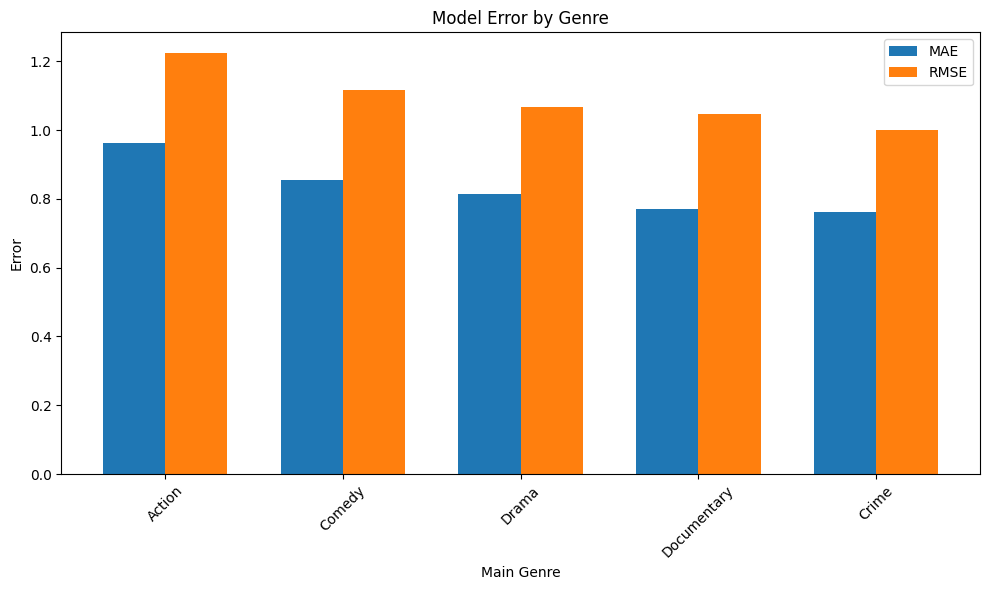

In [136]:
import matplotlib.pyplot as plt
import numpy as np

# Set x positions
x = np.arange(len(genre_fairness_results["main_genre"]))
width = 0.35

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(x - width/2, genre_fairness_results["MAE"], width, label="MAE")
plt.bar(x + width/2, genre_fairness_results["RMSE"], width, label="RMSE")

plt.xticks(x, genre_fairness_results["main_genre"], rotation=45)
plt.xlabel("Main Genre")
plt.ylabel("Error")
plt.title("Model Error by Genre")
plt.legend()
plt.tight_layout()

plt.show()

The chart shows that Action movies have the highest error among the five most common genres, while Crime movies have the lowest error.

This supports the table-based finding that the model does not perform equally across genres.

## Summary of Fairness Analysis by Genre

The genre-based fairness analysis shows that model performance differs across the five most common genres.

The highest error appears for `Action` movies:
- MAE = 0.961
- RMSE = 1.223

The lowest error appears for `Crime` movies:
- MAE = 0.762
- RMSE = 1.001

This suggests that the model is less accurate for Action movies than for some other genres.

Comedy and Drama have intermediate error levels, while Documentary and Crime have lower errors among the five most common genres.

Overall, the model does not perform equally across genres.  
This may be because different genres have different rating patterns, audience expectations, and levels of metadata availability.

The outlier analysis and the genre fairness analysis answer different questions.

The outlier analysis focuses only on the most extreme prediction errors.  
In that analysis, documentaries appeared frequently among the largest overpredictions, meaning that some documentary movies were predicted much too highly.

In contrast, the genre fairness analysis evaluates the average error across all movies in each genre.  
In this broader analysis, Action movies had the highest RMSE and MAE among the five most common genres.

Therefore, there is no contradiction between the two findings.  
Documentaries appear more often among the most extreme overprediction cases, while Action movies have higher average prediction error across the full genre group.

## Fairness Analysis by US vs Non-US Movies

Next, we evaluate whether the model performs differently for US and non-US movies.

We use the engineered feature `is_us`:
- `1` indicates that the movie country information includes the United States.
- `0` indicates that the movie is not identified as a US movie or does not contain US country information.

For each group, we calculate:
- number of movies;
- MAE;
- RMSE.

In [137]:
# Create a readable group label for US vs non-US movies
fairness_df["us_group"] = fairness_df["is_us"].map({
    1: "US",
    0: "Non-US / Unknown"
})

# Calculate MAE and RMSE by US group
us_fairness_results = fairness_df.groupby("us_group").agg(
    n_movies=("actual_rating", "count"),
    MAE=("absolute_error", "mean"),
    RMSE=("squared_error", lambda x: np.sqrt(x.mean()))
).reset_index()

# Sort by RMSE from highest error to lowest error
us_fairness_results = us_fairness_results.sort_values("RMSE", ascending=False)

# Display the results
us_fairness_results

,us_group,n_movies,MAE,RMSE
0,Non-US / Unknown,94382,0.882782,1.151549
1,US,21178,0.727506,0.960225


## US vs Non-US Fairness Visualization

In addition to the table, we visualize MAE and RMSE for US and Non-US / Unknown movies.

This helps compare prediction error between the two country-based groups.
Lower MAE and RMSE values indicate better prediction performance.

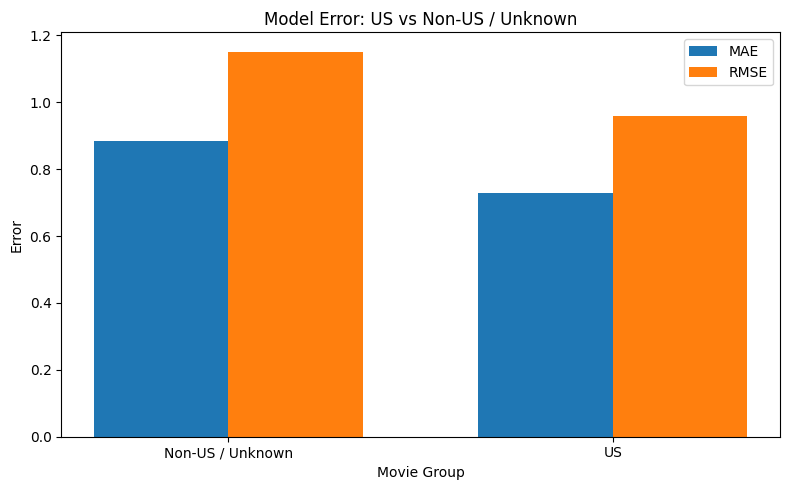

In [138]:
# Set x positions
x = np.arange(len(us_fairness_results["us_group"]))
width = 0.35

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(x - width/2, us_fairness_results["MAE"], width, label="MAE")
plt.bar(x + width/2, us_fairness_results["RMSE"], width, label="RMSE")

plt.xticks(x, us_fairness_results["us_group"])
plt.xlabel("Movie Group")
plt.ylabel("Error")
plt.title("Model Error: US vs Non-US / Unknown")
plt.legend()
plt.tight_layout()

plt.show()

The chart shows that the model has lower MAE and RMSE for US movies compared to Non-US / Unknown movies.

This supports the table-based conclusion that the model performs better on US movies and has higher prediction error for Non-US / Unknown movies.

## Summary of Fairness Analysis by US vs Non-US

The US vs Non-US analysis shows a clear performance difference between the two groups.

For movies identified as US movies:
- MAE = 0.728
- RMSE = 0.960

For movies identified as Non-US or Unknown:
- MAE = 0.883
- RMSE = 1.152

This means that the model performs better on US movies than on Non-US / Unknown movies.

One possible explanation is that US movies may have more consistent or richer metadata in the dataset.  
In contrast, Non-US / Unknown movies may include many cases with missing language, country, plot, or budget information.

This suggests that the model does not perform equally across country-based groups, and that missing or less standardized metadata may reduce prediction accuracy for non-US or unknown-country movies.

## Overall Summary of Fairness Analysis

The fairness analysis evaluated whether the Elastic Net model performs equally across different groups of movies.

Two group-based analyses were performed:

1. Performance by `main_genre`
2. Performance by US vs Non-US / Unknown movies

### Genre-based findings

The genre analysis showed that model performance differs across the five most common genres.

The highest error was found for `Action` movies:
- MAE = 0.961
- RMSE = 1.223

The lowest error was found for `Crime` movies:
- MAE = 0.762
- RMSE = 1.001

This suggests that the model is less accurate for Action movies than for some other common genres.

This does not contradict the earlier outlier analysis.  
The outlier analysis focused only on the most extreme errors, where documentaries appeared frequently among the largest overpredictions.  
The fairness analysis, however, evaluates average error across all movies in each genre.

### US vs Non-US / Unknown findings

The model performs better on movies identified as US movies than on Non-US / Unknown movies.

For US movies:
- MAE = 0.728
- RMSE = 0.960

For Non-US / Unknown movies:
- MAE = 0.883
- RMSE = 1.152

This means that the model has larger prediction errors for Non-US / Unknown movies.

One possible explanation is that US movies may have more consistent or richer metadata in the dataset, while Non-US / Unknown movies may include more missing or less standardized information.

### Conclusion

Overall, the model does not perform equally across all groups.

The main differences found were:
- higher average error for Action movies compared to other common genres;
- higher error for Non-US / Unknown movies compared to US movies.

These findings suggest that future improvements should focus on better representing genre-specific patterns and improving metadata quality for non-US or unknown-country movies.

## Feature Importance Analysis

In this section, we analyze the most important features for each model.

For Elastic Net, feature importance is based on the standardized model coefficients.  
A positive coefficient means that higher values of the feature are associated with higher predicted ratings, while a negative coefficient means that higher values are associated with lower predicted ratings.

For the Decision Tree model, feature importance is based on the tree's `feature_importances_`.  
Decision trees do not have signed coefficients like linear models, so the direction of effect is estimated by checking whether the feature is positively or negatively associated with the model predictions.

Finally, we compare the important features of the two models to see whether they rely on similar signals or different patterns.

In [139]:
# Get feature names after preprocessing
feature_names = best_elastic_net_model.named_steps["preprocessor"].get_feature_names_out()

# Display number of transformed features
len(feature_names)

3328

## Elastic Net Feature Importance

For Elastic Net, we extract the model coefficients after preprocessing.

Because numeric features were scaled using `StandardScaler`, the coefficients are comparable for numeric features.  
Categorical features were one-hot encoded, so each category appears as a separate binary feature.

We rank features by the absolute value of their coefficient and display the five most important features.

In [140]:
# Extract Elastic Net coefficients
elastic_net_coefficients = best_elastic_net_model.named_steps["model"].coef_

# Create a coefficient table
elastic_net_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": elastic_net_coefficients
})

# Add absolute coefficient size
elastic_net_feature_importance["abs_coefficient"] = elastic_net_feature_importance["coefficient"].abs()

# Add direction
elastic_net_feature_importance["direction"] = np.where(
    elastic_net_feature_importance["coefficient"] > 0,
    "Positive",
    "Negative"
)

# Get top 5 most important features
top_5_elastic_net_features = elastic_net_feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
).head(5)

top_5_elastic_net_features

,feature,coefficient,abs_coefficient,direction
41,cat__main_genre_Music,0.712080,0.712080,Positive
1042,cat__main_language_Hindi,-0.633516,0.633516,Negative
1407,cat__main_language_Marathi,0.423763,0.423763,Positive
47,cat__main_genre_Sci-Fi,-0.362730,0.362730,Negative
12,num__is_documentary,0.346665,0.346665,Positive


## Decision Tree Feature Importance

For the Decision Tree model, we first fit the full pipeline on the full training data.

Then we extract `feature_importances_` from the trained tree model.  
These values indicate how much each feature contributed to reducing prediction error inside the tree.

Since tree-based importance values do not have a positive or negative sign, we estimate the direction by checking whether each feature is positively or negatively correlated with the model predictions.

In [141]:
# Fit the Decision Tree pipeline on the full prepared training data
decision_tree_pipeline.fit(X_prepared, y)

# Get transformed feature names from the fitted preprocessor
dt_feature_names = decision_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Extract feature importances from the Decision Tree model
dt_importances = decision_tree_pipeline.named_steps["model"].feature_importances_

# Create feature importance table
decision_tree_feature_importance = pd.DataFrame({
    "feature": dt_feature_names,
    "importance": dt_importances
})

# Sort by importance
decision_tree_feature_importance = decision_tree_feature_importance.sort_values(
    "importance",
    ascending=False
)

# Display top 5 before adding direction
decision_tree_feature_importance.head(5)

,feature,importance
12,num__is_documentary,0.317301
14,num__is_horror,0.216934
1,num__runtimeMinutes,0.168013
10,num__is_drama,0.072623
0,num__startYear,0.048650


In [142]:
# Transform X_prepared using the fitted preprocessor
X_transformed_dt = decision_tree_pipeline.named_steps["preprocessor"].transform(X_prepared)

# Get Decision Tree predictions on the full training data
dt_full_predictions = decision_tree_pipeline.predict(X_prepared)

# Function to estimate direction based on correlation with predictions
def estimate_feature_direction(transformed_matrix, feature_index, predictions):
    """
    Estimate whether a transformed feature is positively or negatively associated
    with model predictions.
    """
    feature_values = transformed_matrix[:, feature_index]
    
    # Convert sparse column to dense if needed
    if hasattr(feature_values, "toarray"):
        feature_values = feature_values.toarray().ravel()
    else:
        feature_values = np.asarray(feature_values).ravel()
    
    # If the feature has no variation, direction is unclear
    if np.std(feature_values) == 0:
        return "Unknown"
    
    corr = np.corrcoef(feature_values, predictions)[0, 1]
    
    if corr > 0:
        return "Positive"
    elif corr < 0:
        return "Negative"
    else:
        return "Unknown"

# Get top 5 Decision Tree features
top_5_decision_tree_features = decision_tree_feature_importance.head(5).copy()

# Add feature index
top_5_decision_tree_features["feature_index"] = top_5_decision_tree_features["feature"].apply(
    lambda f: list(dt_feature_names).index(f)
)

# Estimate direction for each top feature
top_5_decision_tree_features["estimated_direction"] = top_5_decision_tree_features["feature_index"].apply(
    lambda idx: estimate_feature_direction(X_transformed_dt, idx, dt_full_predictions)
)

# Display final top 5 Decision Tree features
top_5_decision_tree_features[
    ["feature", "importance", "estimated_direction"]
]

,feature,importance,estimated_direction
12,num__is_documentary,0.317301,Positive
14,num__is_horror,0.216934,Negative
1,num__runtimeMinutes,0.168013,Positive
10,num__is_drama,0.072623,Positive
0,num__startYear,0.048650,Negative


## Summary of Feature Importance Analysis

The transformed feature matrix contains 3,328 features after preprocessing and one-hot encoding.

### Elastic Net

For Elastic Net, feature importance was based on the absolute value of the standardized coefficients.

The top 5 most important features were:

1. `main_genre_Music` — positive coefficient  
2. `main_language_Hindi` — negative coefficient  
3. `main_language_Marathi` — positive coefficient  
4. `main_genre_Sci-Fi` — negative coefficient  
5. `is_documentary` — positive coefficient  

The positive coefficients suggest that these features are associated with higher predicted ratings, while negative coefficients suggest association with lower predicted ratings.

For example, `main_genre_Music` and `is_documentary` increased predicted ratings, while `main_genre_Sci-Fi` and `main_language_Hindi` decreased predicted ratings in the Elastic Net model.

### Decision Tree

For the Decision Tree model, feature importance was based on the tree's `feature_importances_`.

The top 5 most important features were:

1. `is_documentary` — estimated positive direction  
2. `is_horror` — estimated negative direction  
3. `runtimeMinutes` — estimated positive direction  
4. `is_drama` — estimated positive direction  
5. `startYear` — estimated negative direction  

This means that the Decision Tree relied strongly on genre indicators and basic numeric features such as runtime and year.

The estimated directions suggest that documentary and drama features tended to increase predictions, while horror and later release year were associated with lower predictions.

## Comparison of Feature Importance Between Models

The two models partially agree on important signals, but they do not rely on exactly the same features.

Both models identify documentary-related information as important:
- Elastic Net includes `is_documentary` among its top 5 features with a positive coefficient.
- Decision Tree ranks `is_documentary` as the most important feature, also with an estimated positive direction.

This is consistent with the error analysis, where documentaries appeared frequently among the largest overpredictions.  
The models seem to associate documentary-related features with higher ratings, which helps in many cases but also causes large errors for low-rated documentaries.

The models differ in other important features.

Elastic Net gives high importance to specific one-hot encoded categories, such as:
- `main_genre_Music`
- `main_language_Hindi`
- `main_language_Marathi`
- `main_genre_Sci-Fi`

This makes sense because Elastic Net is a linear model and assigns separate coefficients to each encoded category.

In contrast, the Decision Tree relies more on broader structural features, such as:
- `is_documentary`
- `is_horror`
- `runtimeMinutes`
- `is_drama`
- `startYear`

This difference is expected because Decision Trees split the data based on feature thresholds and binary indicators, while Elastic Net combines all features linearly.

Overall, both models agree that genre-related features are important, but Elastic Net focuses more on specific encoded categories, while the Decision Tree focuses more on broad genre indicators and numeric metadata.

## Final Model for Held-Out Test Set

For the held-out test set, the instructor may run the following sequence:

`X = prepare_data(df_2025)`  
`y_pred = model.predict(X)`

Therefore, we define a final variable named `model`.

The final selected model is the best Elastic Net pipeline found by GridSearchCV, because it achieved slightly better cross-validation results than the Decision Tree model.

The `model` object already includes both:
- the preprocessing pipeline;
- the trained Elastic Net model.

The expected input for `model.predict()` is the output of `prepare_data(df)`.

In [143]:
# Define the final model for external evaluation
model = elastic_net_grid_search.best_estimator_

# The final model expects input after prepare_data(df)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Final Sanity Check

Before submission, we verify that the final model can predict ratings from the output of `prepare_data`.

This simulates the expected held-out test flow:

1. apply `prepare_data` to a raw DataFrame;
2. pass the prepared features into `model.predict`.

In [144]:
# Simulate the held-out test flow using a small sample from the training data
sample_raw = df_train.head(5).copy()

# Apply prepare_data
sample_X = prepare_data(sample_raw)

# Generate predictions using the final model
sample_predictions = model.predict(sample_X)

# Display predictions
sample_predictions

array([6.27371057, 5.85950698, 5.70836318, 7.28697982, 8.12645573])

X = prepare_data(df_new)
y_pred = model.predict(X)

## Saving the Final Trained Model

The final selected model is the best Elastic Net pipeline found by GridSearchCV.

This model includes:
- the preprocessing pipeline;
- the trained Elastic Net model with the best hyperparameters.

The model is saved to a file named `model.pkl` using `joblib`, so it can be loaded later during the held-out test evaluation.

The expected prediction flow is:

`X = prepare_data(df_new)`  
`y_pred = model.predict(X)`

In [145]:
# Import joblib for saving and loading trained models
import joblib

# Define the final trained model
model = elastic_net_grid_search.best_estimator_

# Save the trained model to a pickle file
joblib.dump(model, "model.pkl")

['model.pkl']

## Testing the Saved Model

After saving the model, we load it back from `model.pkl` and test that it can generate predictions.

This verifies that the serialized model file was saved correctly and can be used later during the held-out test evaluation.

In [146]:
# Load the saved model
loaded_model = joblib.load("model.pkl")

# Test prediction flow on a small sample
sample_raw = df_train.head(5).copy()
sample_X = prepare_data(sample_raw)

sample_predictions = loaded_model.predict(sample_X)

# Display predictions
sample_predictions

array([6.27371057, 5.85950698, 5.70836318, 7.28697982, 8.12645573])